### Testing code functionality
Amy - Sep 2026

***Maria's note***:
**Changes from Amy's notebook (dataset setup):**
- 20 x 20 D–T2 points instead of 10 x 10.
- 8 b-values (0-4) s 8 TEs (20–180 ms) instead of 20 b-values (0–10) s 20 TEs (10–200 ms), so far fewer measurements per voxel
- More voxels, 80 instead of 12.
- SVD rank R = 10 instead of 8
- New true compartments, the same as in demo_pipeline: centres at (D, T2) = (0.4, 90), (0.9, 55), (1.6, 120), with a different width for each
- Added a mean version of the NNLS initialisation (define_initial_C_NNLS_mean in optimiser), which averages the signals before solving NNLS
- Sections 3 and 4 use their own fixed random seed, so they run on the same data and can be compared


#### First create some GT spectra

In [24]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *
from metrics import voxelwise_spectrum_mae

rng=np.random.default_rng(40)

In [35]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=[0, 5, 12, 17]):
    fig, axes = plt.subplots(
        3, len(voxels_to_show),
        figsize=(3.2 * len(voxels_to_show), 8.5),
        constrained_layout=True,
    )

    for col, voxel in enumerate(voxels_to_show):
        for row, (name, F) in enumerate([("Ground truth", F_true), ("Estimated", F_est)]):
            image = axes[row, col].imshow(
                F[:, voxel].reshape(nD, nT2),
                origin="lower",
                aspect="auto",
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()],
            )
            axes[row, col].set_title(f"{name}: voxel {voxel}")
            axes[row, col].set_xlabel("T2 (ms)")
            axes[row, col].set_ylabel("D")
            fig.colorbar(image, ax=axes[row, col], shrink=0.75)

        # The third row reports the component weights that form this spectrum.
        components = np.arange(W_true.shape[0])
        axes[2, col].bar(components - 0.18, W_true[:, voxel], 0.36, label="Ground truth")
        axes[2, col].bar(components + 0.18, W_est[:, voxel], 0.36, label="Estimated")
        axes[2, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components],
                         ylim=(0, 1), title=f"Weights: voxel {voxel}", ylabel="weight")
        if col == 0:
            axes[2, col].legend()

    plt.show()

def order_components(C_true, C_est, W_est, K):
    # Cost[i, j] = dissimilarity between true component i and estimated component j.
    cost = np.array([
        [np.mean((C_true[:, i] - C_est[:, j]) ** 2) for j in range(K)]
        for i in range(K)
    ])

    true_indices, estimated_indices = linear_sum_assignment(cost)

    # Put estimated components into the ground-truth component order.
    order = estimated_indices[np.argsort(true_indices)]

    C_est = C_est[:, order]
    W_est = W_est[order, :]
    return C_est, W_est

def show_weight_correlations(W_est, W_true=None):
    K = W_est.shape[0]
    pairs = [(i, j) for i in range(K) for j in range(i + 1, K)]
    n_rows = 1 if W_true is None else 2
    fig, axes = plt.subplots(n_rows, max(len(pairs), K), figsize=(3.5 * max(len(pairs), K), 3.5 * n_rows),
                             squeeze=False, constrained_layout=True)

    # Row 1: weight k vs weight l across voxels (each point is one voxel)
    for col, (i, j) in enumerate(pairs):
        r = np.corrcoef(W_est[i], W_est[j])[0, 1]
        axes[0, col].scatter(W_est[i], W_est[j], s=12, alpha=0.7)
        axes[0, col].set(xlim=(0, 1), ylim=(0, 1), xlabel=f"W{i + 1}", ylabel=f"W{j + 1}",
                         title=f"W{i + 1} vs W{j + 1}, r = {r:.2f}")

    # Row 2 (simulation only): estimated vs true weight for each component
    if W_true is not None:
        for k in range(K):
            r = np.corrcoef(W_true[k], W_est[k])[0, 1]
            axes[1, k].scatter(W_true[k], W_est[k], s=12, alpha=0.7)
            axes[1, k].plot([0, 1], [0, 1], "k--", lw=1)
            axes[1, k].set(xlim=(0, 1), ylim=(0, 1), xlabel=f"true W{k + 1}", ylabel=f"estimated W{k + 1}",
                           title=f"W{k + 1}: true vs estimated, r = {r:.2f}")

    for ax in axes.flat[len(pairs) if W_true is None else len(axes.flat):]:
        ax.axis("off")
    plt.show()


b values  [ 0.   1.   2.5  5.   7.5 11.1 18.1 25. ] 

TE values [28.12  33.    38.017 45.    60.    78.   ] 



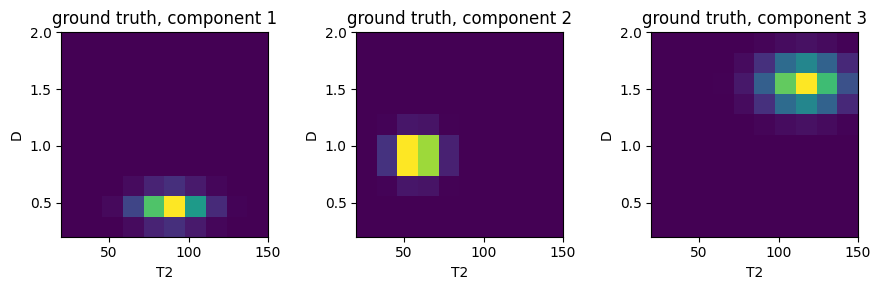

In [26]:

Dmin, T2min, Dmax, T2max, nD, nT2 = 0.2, 20.0, 2.0, 150.0, 10, 10

voxels_to_show = [10, 20, 30, 40, 50, 60, 70]

# three ground-truth compartments, each a Gaussian blob in (D, T2) space
D_means = [0.4, 0.9, 1.6]
D_stds = [0.10, 0.12, 0.16]
T2_means = [90, 55, 120]
T2_stds = [15, 10, 18]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

# acquisition of the real macaque data
b_vals = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0, 18100.0, 25000.0]) / 1000.0   # s/mm² -> ms/µm² (same units as D)
TE_vals = np.array([28.12, 33.0, 38.017, 45.0, 60.0, 78.0])   # ms
print("b values ", b_vals, "\n")
print("TE values", TE_vals, "\n")

# Define fitting parameters
K=3; # Number of canonical spectra
V=80; # Number of voxels
R=10   # Rank for SVD    

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2); 
# Create A matrix from b_vals x TE_vals, b-major (b outer, TE inner) like create_A_matrix,
# so initialize_M0_monoexponential(Y, b_vals, TE_vals) expands the rows in the same order
B_mesh, TE_mesh = np.meshgrid(b_vals, TE_vals, indexing="ij")
A = create_A_matrix_from_acquisition(D, T2, B_mesh.ravel(), TE_mesh.ravel())
# Create true C - canonical spectra
# Here have hardcoded centres
C_true = create_gaussian_compartments(D_grid, T2_grid, D_means, D_stds, T2_means, T2_stds)

# Define GT weights
W_true = rng.uniform(size=(K, V))
W_true /= W_true.sum(axis=0, keepdims=True)

# Set scale parameter
M0_true=np.ones(V)*300;

# Calulate the signal Y = M0 * A * C_true * W_true
SNR = 50
sigma = M0_true/SNR # sigma needs to scale with M0
Y=create_signal(A,C_true,W_true,M0_true,sigma,rng)

# Create GT C_small using SVD
U,s,Vmat=apply_SVD_to_A(A,R)
C_small_true=project_C_to_C_small(C_true,s,Vmat)
#C_small_true = np.diag(s) @ V_mat.T @ C_true - should be equivalent

show_canonical_spectra([('ground truth', C_true)])


#### Run optimisation

I added a function, define_initial_C_NNLS_mean, that averages the signals over all voxels first and then solves one NNLS on the average. The original define_initial_C_NNLS solves NNLS on each voxel and averages the spectra. Both then use k-means on the averaged spectrum to find the component centres and place one Gaussian at each centre.

**Result:** The original (spectrum-averaged) version puts the components in the wrong places here. The new signal-averaged version finds all three in the right places. Only the second is kept, so everything below starts from the signal-averaged initialisation.


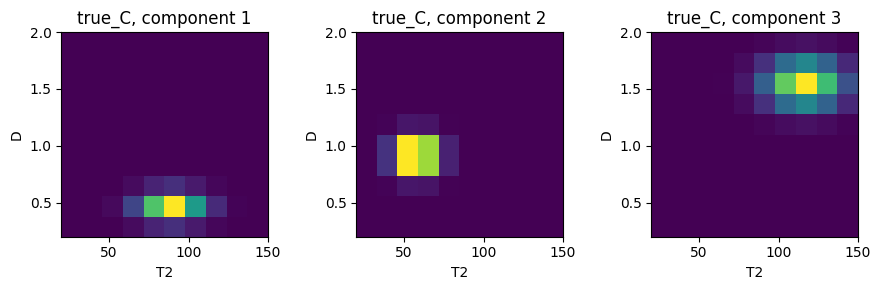

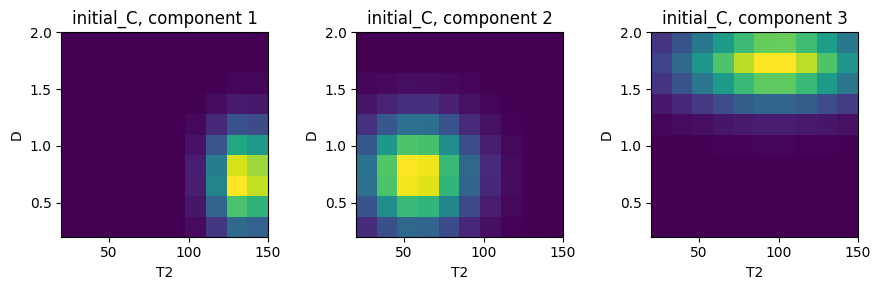

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Initial M0: [318.94368978 297.05390342 289.90605159 314.02506943 312.3713705
 282.67461885 301.55656265 280.96060569 291.70486222 289.64346611
 306.19924823 295.95827806 295.52732356 276.11926561 296.20969466
 283.24086311 307.0797484  318.5233281  272.6500218  294.05018166
 297.37254537 301.61070668 294.52220583 284.38015215 290.32770314
 287.9470258  279.83209517 282.74462836 282.62085018 294.35080819
 297.31219285 292.71701901 280.28445521 301.95429997 290.35876031
 298.20790355 282.3203458  308.75370296 276.21151987 267.1657098
 302.70043076 295.54073012 312.05807785 302.81

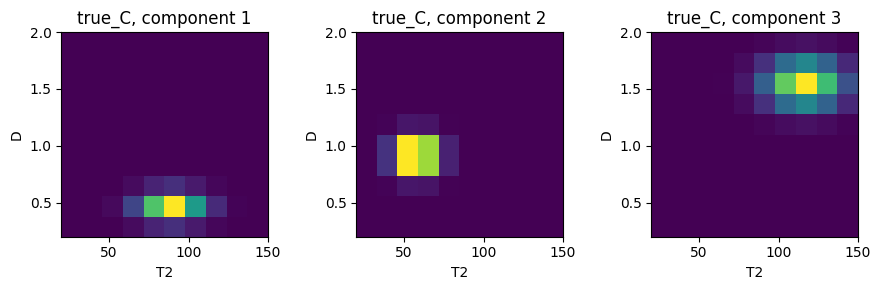

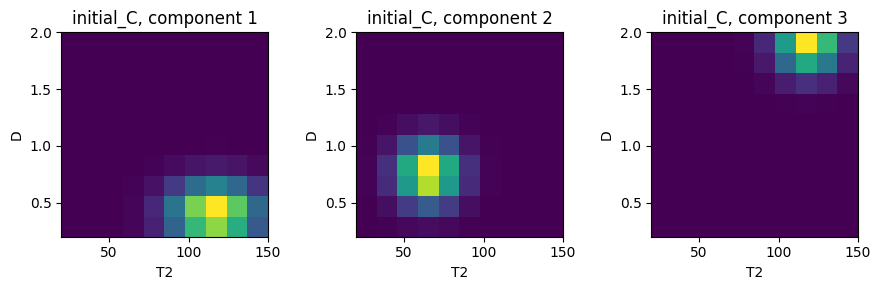

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Initial M0: [318.94368978 297.05390342 289.90605159 314.02506943 312.3713705
 282.67461885 301.55656265 280.96060569 291.70486222 289.64346611
 306.19924823 295.95827806 295.52732356 276.11926561 296.20969466
 283.24086311 307.0797484  318.5233281  272.6500218  294.05018166
 297.37254537 301.61070668 294.52220583 284.38015215 290.32770314
 287.9470258  279.83209517 282.74462836 282.62085018 294.35080819
 297.31219285 292.71701901 280.28445521 301.95429997 290.35876031
 298.20790355 282.3203458  308.75370296 276.21151987 267.1657098
 302.70043076 295.54073012 312.05807785 302.81

In [27]:
# Set intial conditions
C0=define_initial_C_NNLS(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0=project_C_to_C_small(C0,s,Vmat); 

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

C0,W0=order_components(C_true, C0, W0, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
print("True M0:", M0_true)
print("Initial M0:", M0_init)

# Set intial conditions
C0=define_initial_C_NNLS_mean(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0=project_C_to_C_small(C0,s,Vmat); 

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

C0,W0=order_components(C_true, C0, W0, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
print("True M0:", M0_true)
print("Initial M0:", M0_init)





Seed 0: true C (first row) vs initial C (second row), starting W MAE 0.199


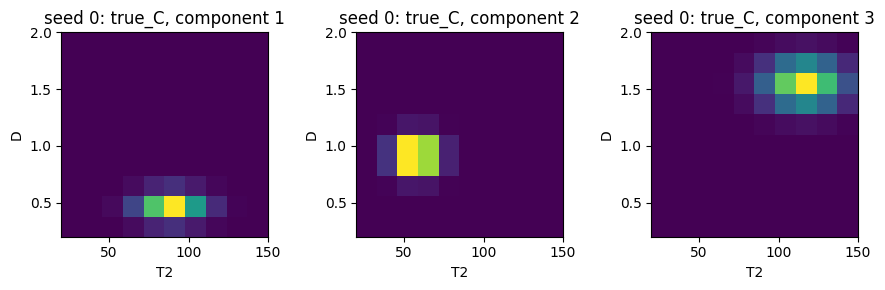

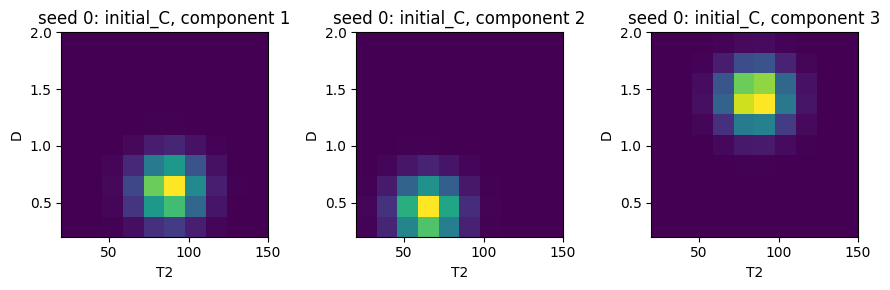



iter 0: loss=2632.4849, fit_err=193386.028643, sigma2=36.000000, lam=0.0100, alpha=1.0000
iter 100: loss=2036.0840, fit_err=154115.562276, sigma2=36.000000, lam=0.0100, alpha=0.4598
iter 200: loss=2031.6885, fit_err=153878.569710, sigma2=36.000000, lam=0.0100, alpha=0.4565
Seed 0, dirichlet prior: estimated C, W MAE 0.104


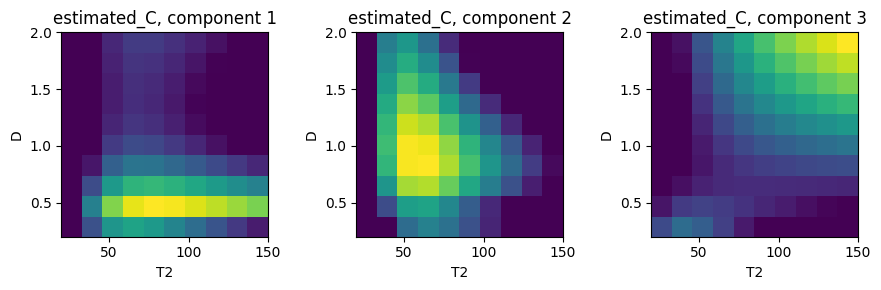

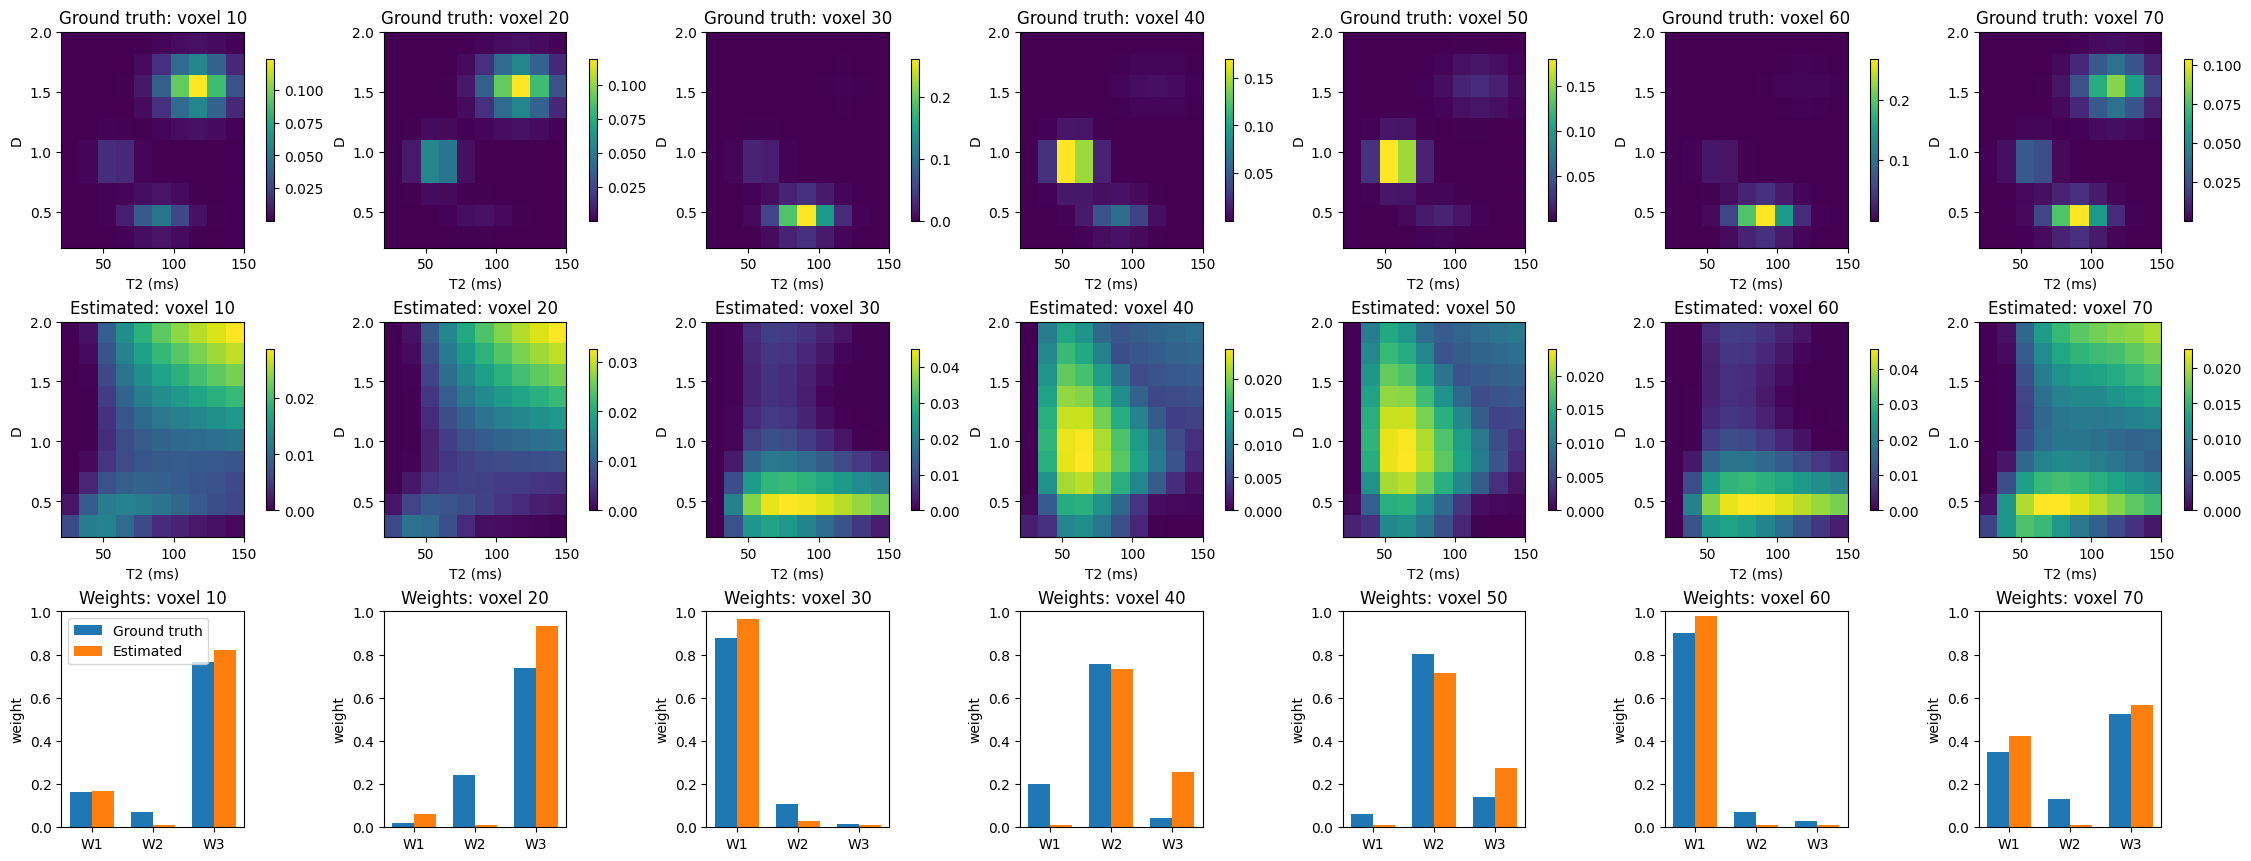

iter 0: loss=3239.3832, fit_err=204668.072856, sigma2=36.000000, lam=0.0100, alpha=1.0000
iter 100: loss=2720.1543, fit_err=168343.459502, sigma2=36.000000, lam=0.0100, alpha=1.0000
iter 200: loss=2704.5258, fit_err=169550.340340, sigma2=36.000000, lam=0.0100, alpha=1.0000
Seed 0, entropy prior: estimated C, W MAE 0.235


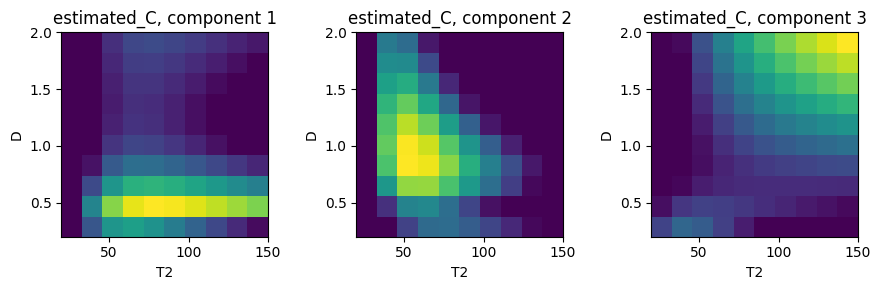

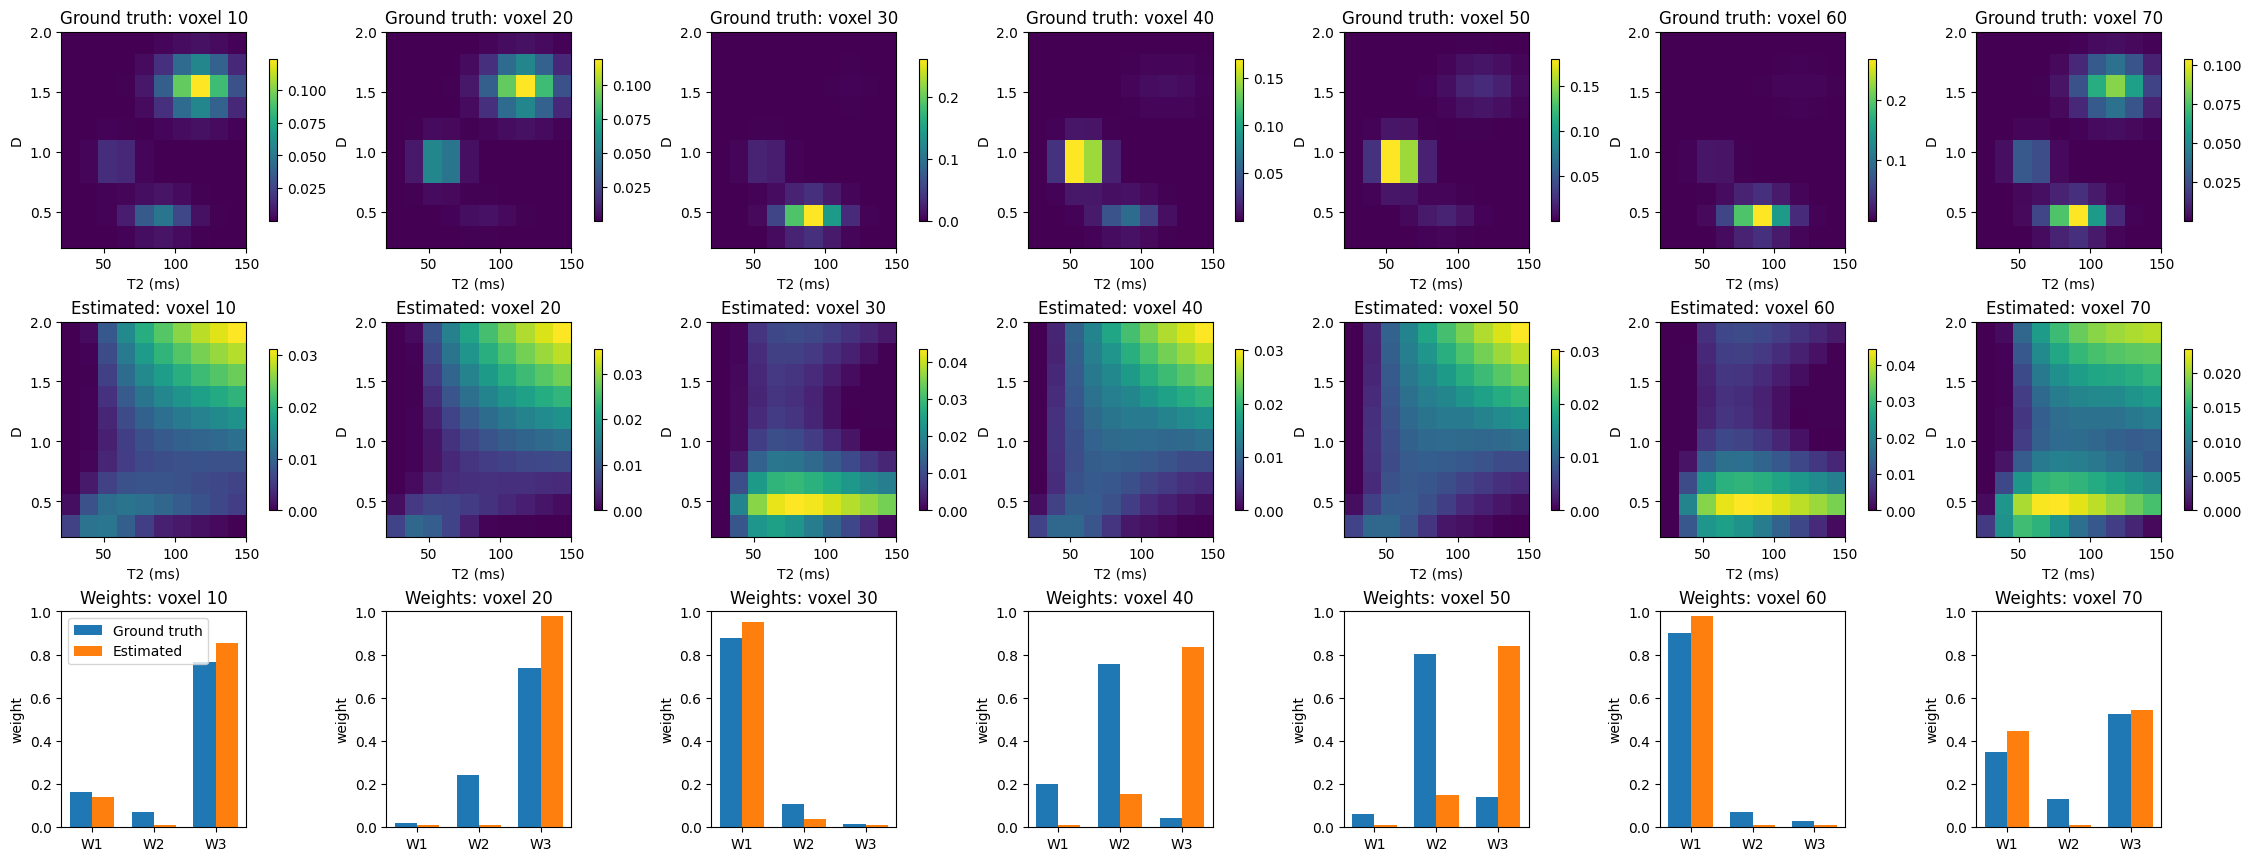

W MAE per seed: start, dirichlet, entropy
[[0.199 0.104 0.235]]
mean: [0.199 0.104 0.235]


In [28]:
# Dirichlet vs entropy prior on the same data, over several seeds
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

rows = []
for seed in range(1):
    rng_seed = np.random.default_rng(seed)
    alpha_true = 0.5
    W_true_dirichlet = rng_seed.dirichlet(alpha_true * np.ones(K), size=V).T

    # Calulate the signal Y = M0 * A * C_true * W_true
    Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_seed)

    # Set intial conditions
    C0_dirichlet=define_initial_C_NNLS_mean(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
    #^^^ This function could be re-written to not have so many arguments 
    Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

    M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

    print(f"Seed {seed}: true C (first row) vs initial C (second row), starting W MAE {np.mean(np.abs(W_true_dirichlet - W0_dirichlet)):.3f}")
    show_canonical_spectra([(f'seed {seed}: true_C', C_true)])
    show_canonical_spectra([(f'seed {seed}: initial_C', C0_dirichlet)])
    print("\n")


    # ----------------


    R = 7
    U, s, Vmat = apply_SVD_to_A(A, R)

    # C0 stays on the physical D–T2 grid, so it does not depend on R.
    Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

    # Refit weights because U @ Csmall0 has changed.
    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    errors = [np.mean(np.abs(W_true_dirichlet - W0_dirichlet))]
    for name, kwargs in priors.items():
        W_est_dirichlet, _, Csmall_est_dirichlet, *_ = run_optimisation(
            Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, K=K, R=R, eps=1e-10, n_iter=300,
            sigma2=np.mean(sigma**2), lam=1e-2, W=W0_dirichlet.copy(),
            update_W_flag=True, update_C_flag=True, update_M0_flag=True,
            m0_prior=M0_init_dirichlet, m0_prior_sigma=0.15, alpha=1.0, alpha_update_start=5,
            verbose_every=100, **kwargs)
        C_est_dirichlet, W_est_dirichlet = order_components(C_true, estimate_C(Vmat, s, Csmall_est_dirichlet), W_est_dirichlet, K)
        errors.append(np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
        print(f"Seed {seed}, {name} prior: estimated C, W MAE {errors[-1]:.3f}")
        show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])

        F_true = C_true @ W_true_dirichlet
        F_est = C_est_dirichlet @ W_est_dirichlet
        show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show)

    rows.append(errors)

print("W MAE per seed: start, dirichlet, entropy")
print(np.round(rows, 3))
print("mean:", np.round(np.mean(rows, axis=0), 3))


Seed 0: true C (first row) vs initial C (second row), starting W MAE 0.199


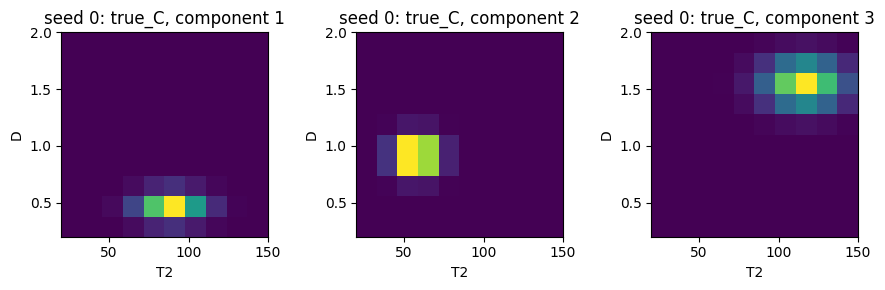

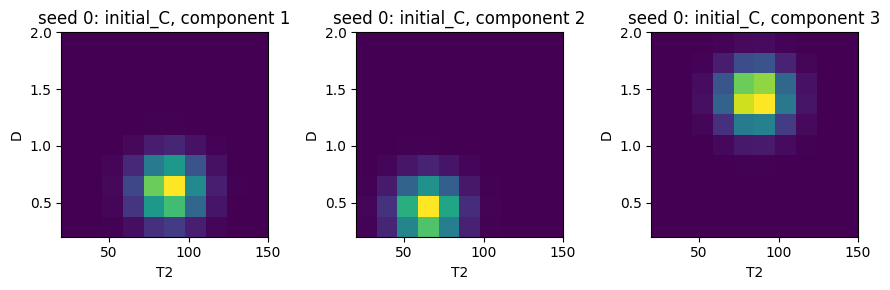



iter 0: loss=2306.3111, fit_err=158335.998322, sigma2=36.000000
iter 100: loss=2011.3937, fit_err=145504.484788, sigma2=36.000000
iter 200: loss=2011.3932, fit_err=145504.443194, sigma2=36.000000
Seed 0, dirichlet prior: estimated C, W MAE 0.159


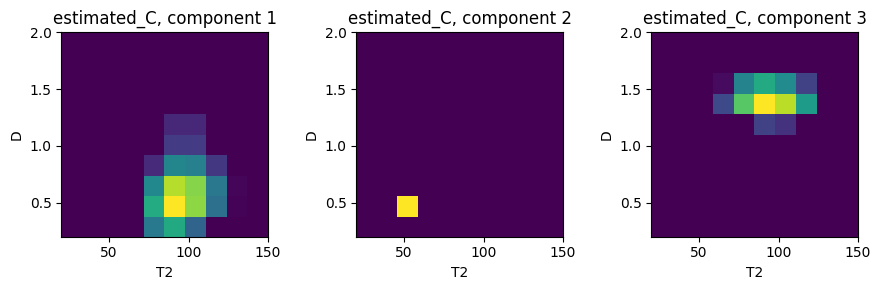

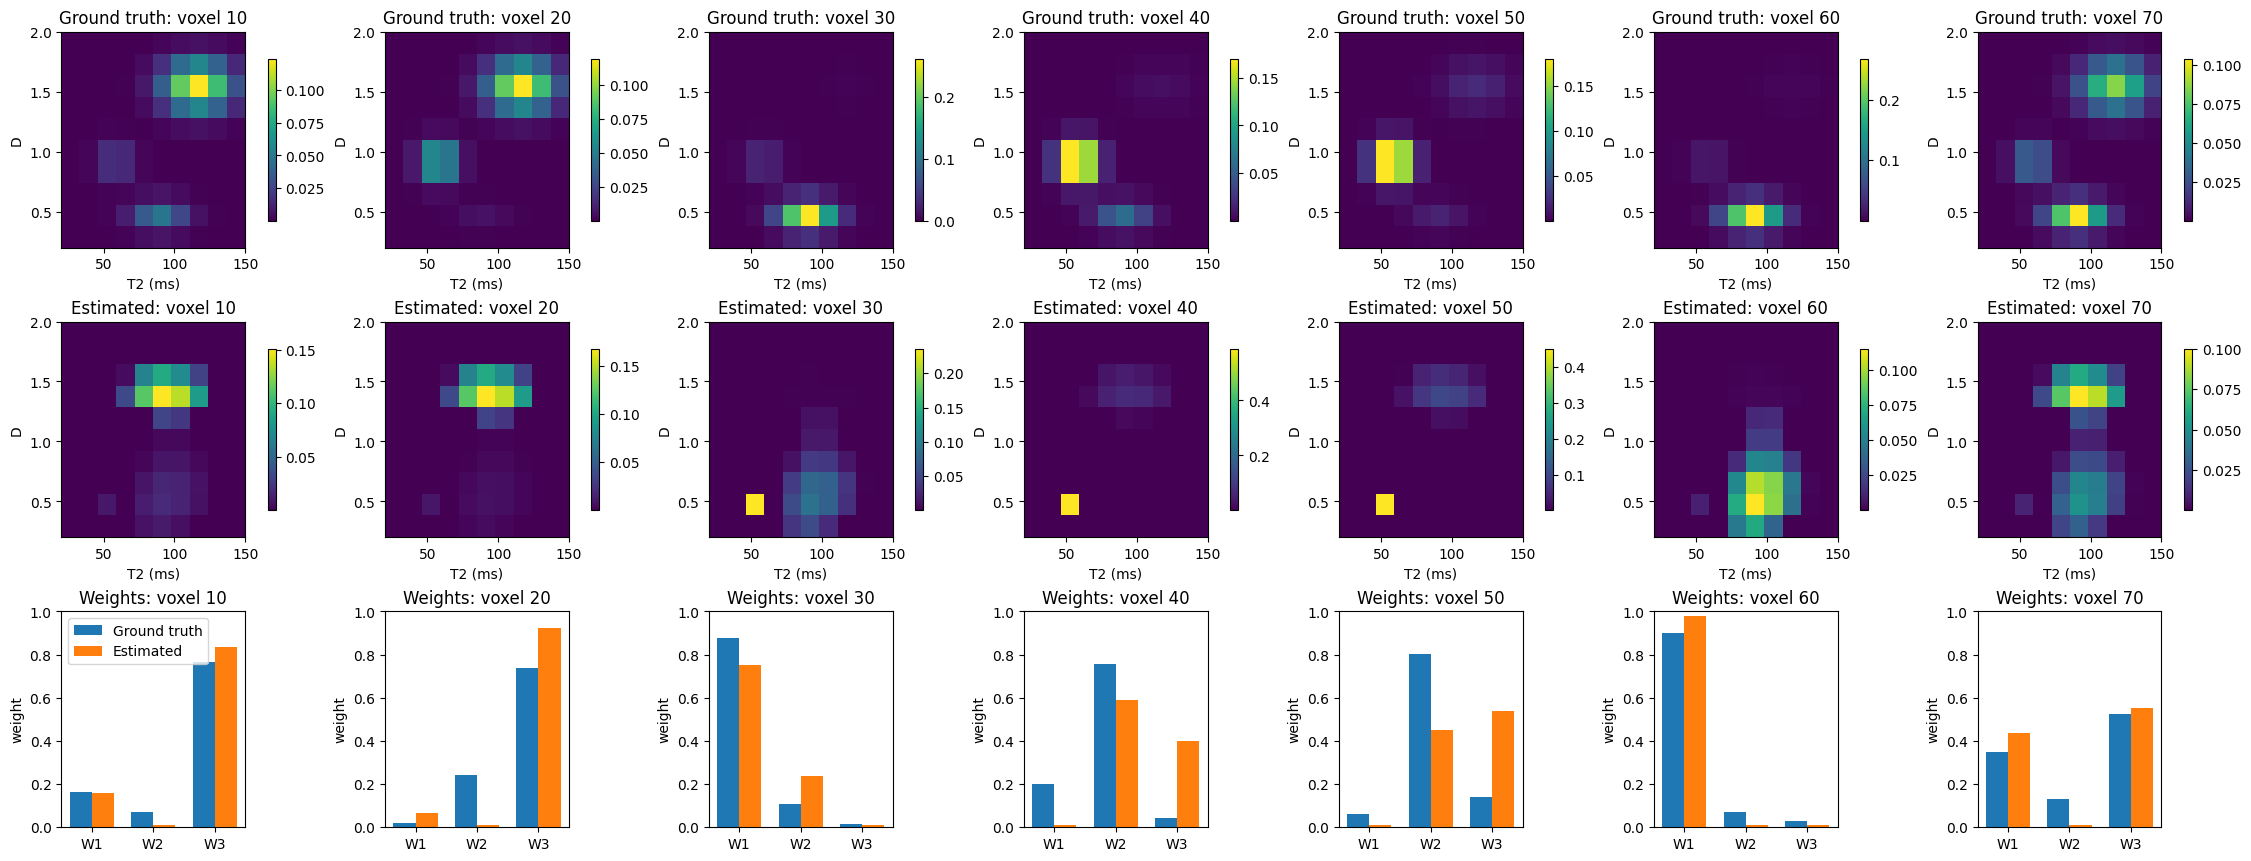

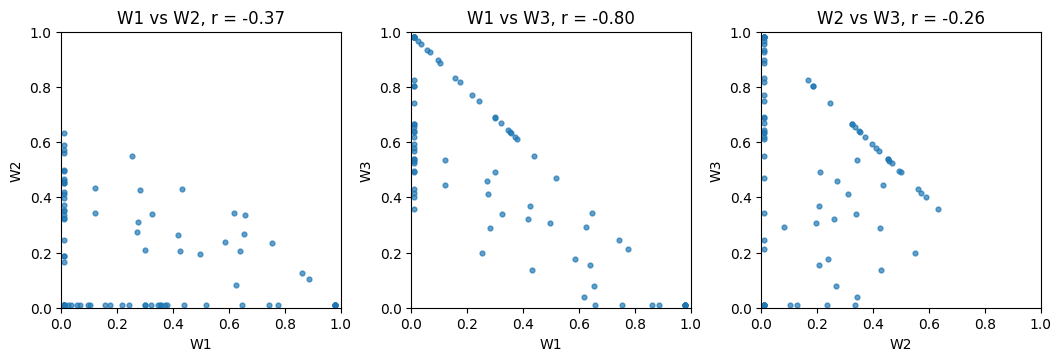

iter 0: loss=2769.5213, fit_err=159128.085303, sigma2=36.000000
iter 100: loss=2533.6508, fit_err=147911.192186, sigma2=36.000000
iter 200: loss=2533.6502, fit_err=147911.615869, sigma2=36.000000
Seed 0, entropy prior: estimated C, W MAE 0.174


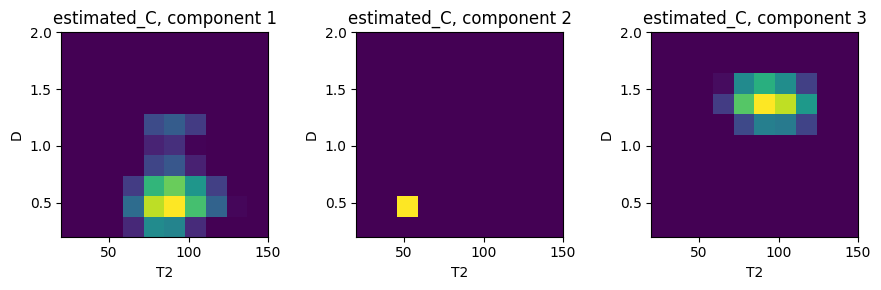

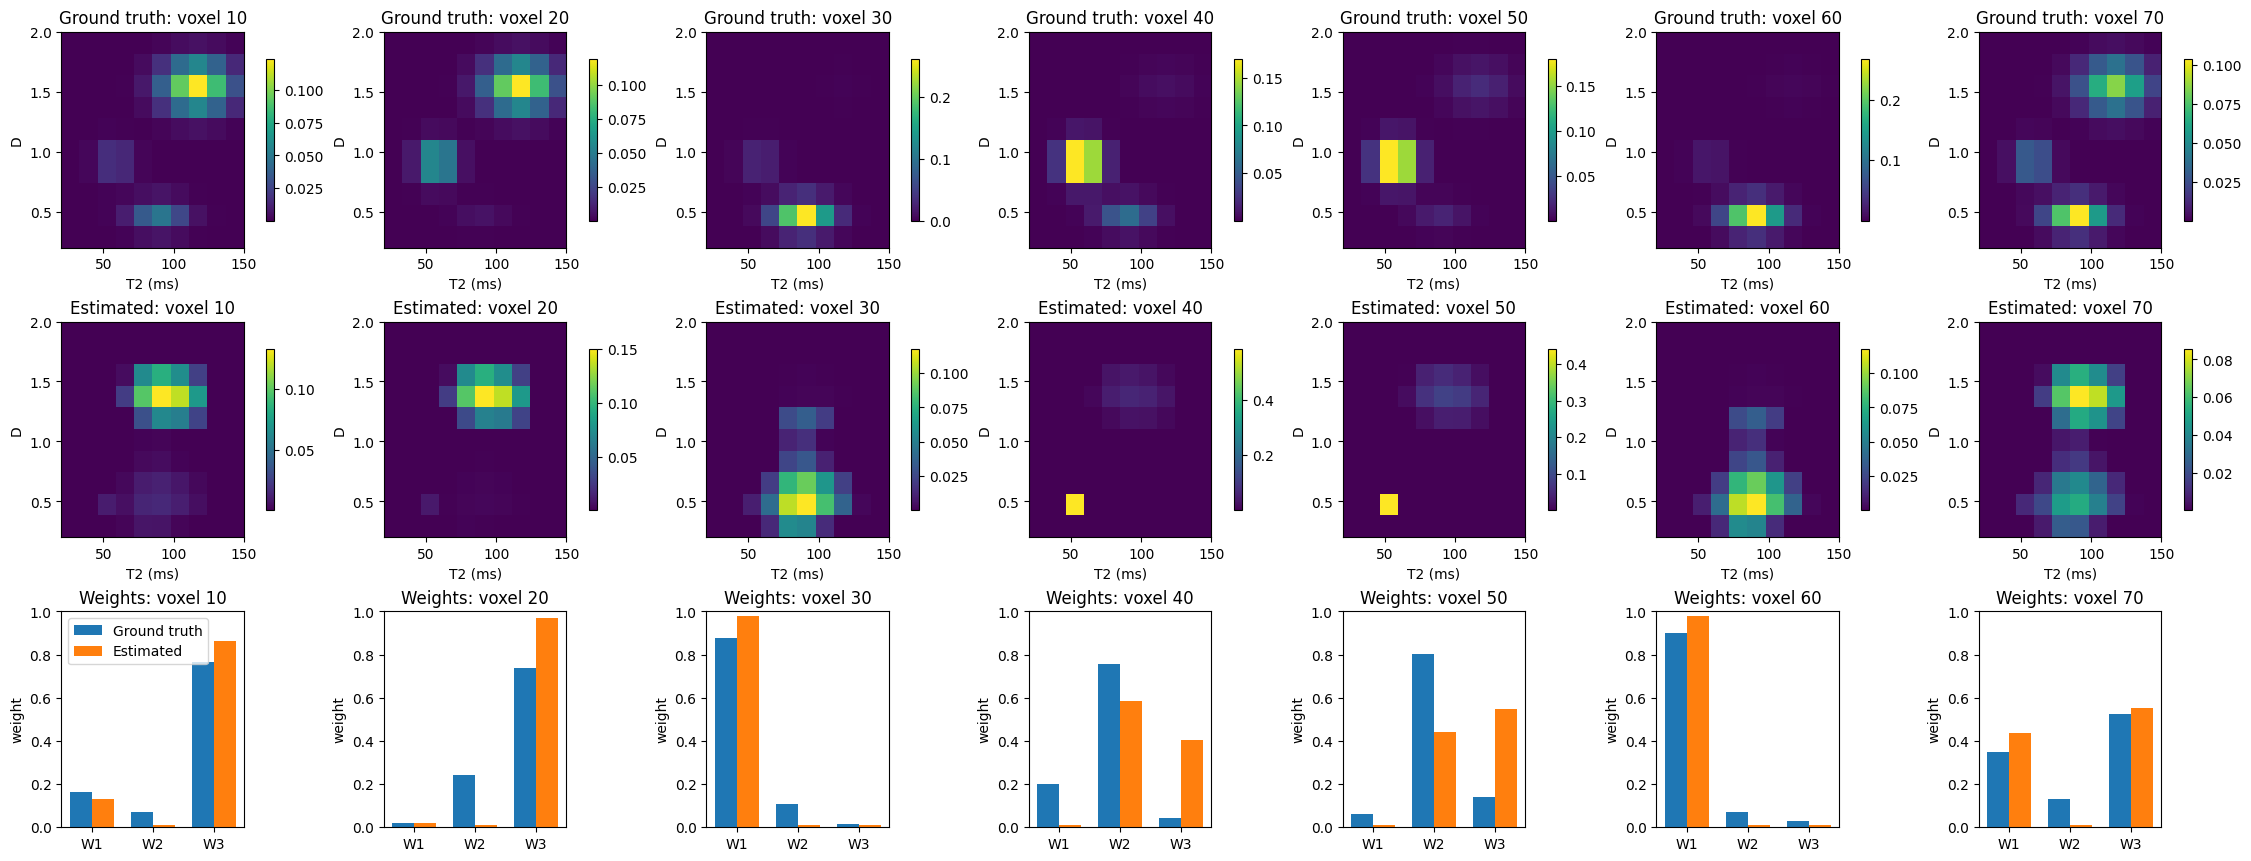

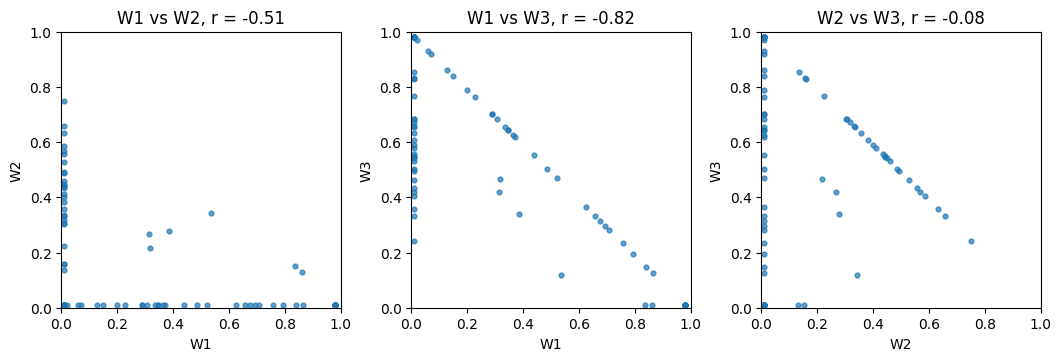

Seed 1: true C (first row) vs initial C (second row), starting W MAE 0.280


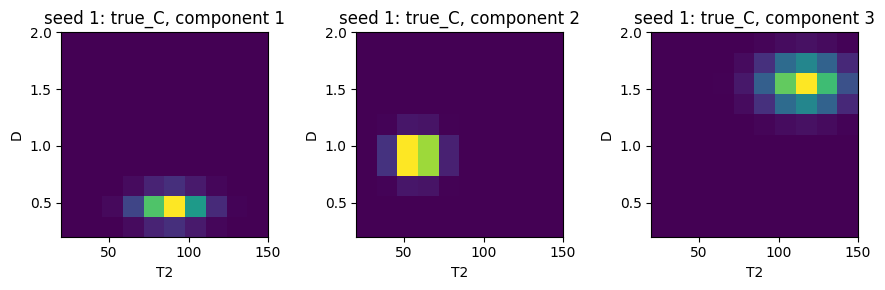

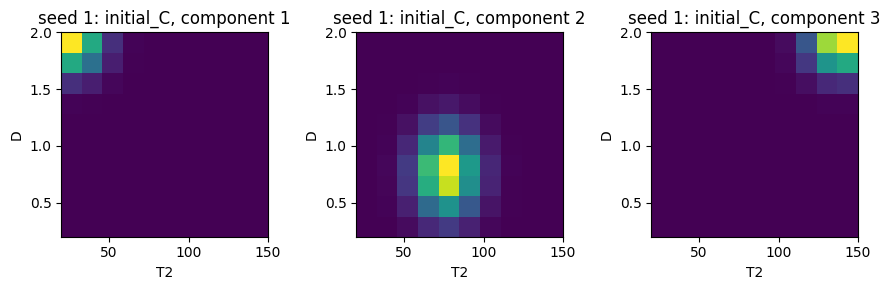



iter 0: loss=2630.9086, fit_err=180086.184252, sigma2=36.000000
iter 100: loss=2026.3826, fit_err=148773.535992, sigma2=36.000000
iter 200: loss=2026.3819, fit_err=148772.925708, sigma2=36.000000
Seed 1, dirichlet prior: estimated C, W MAE 0.167


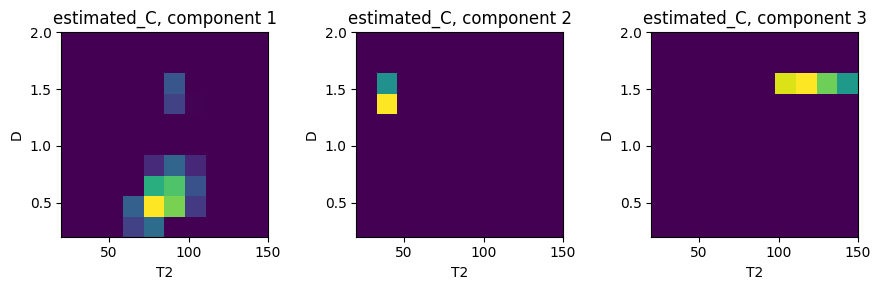

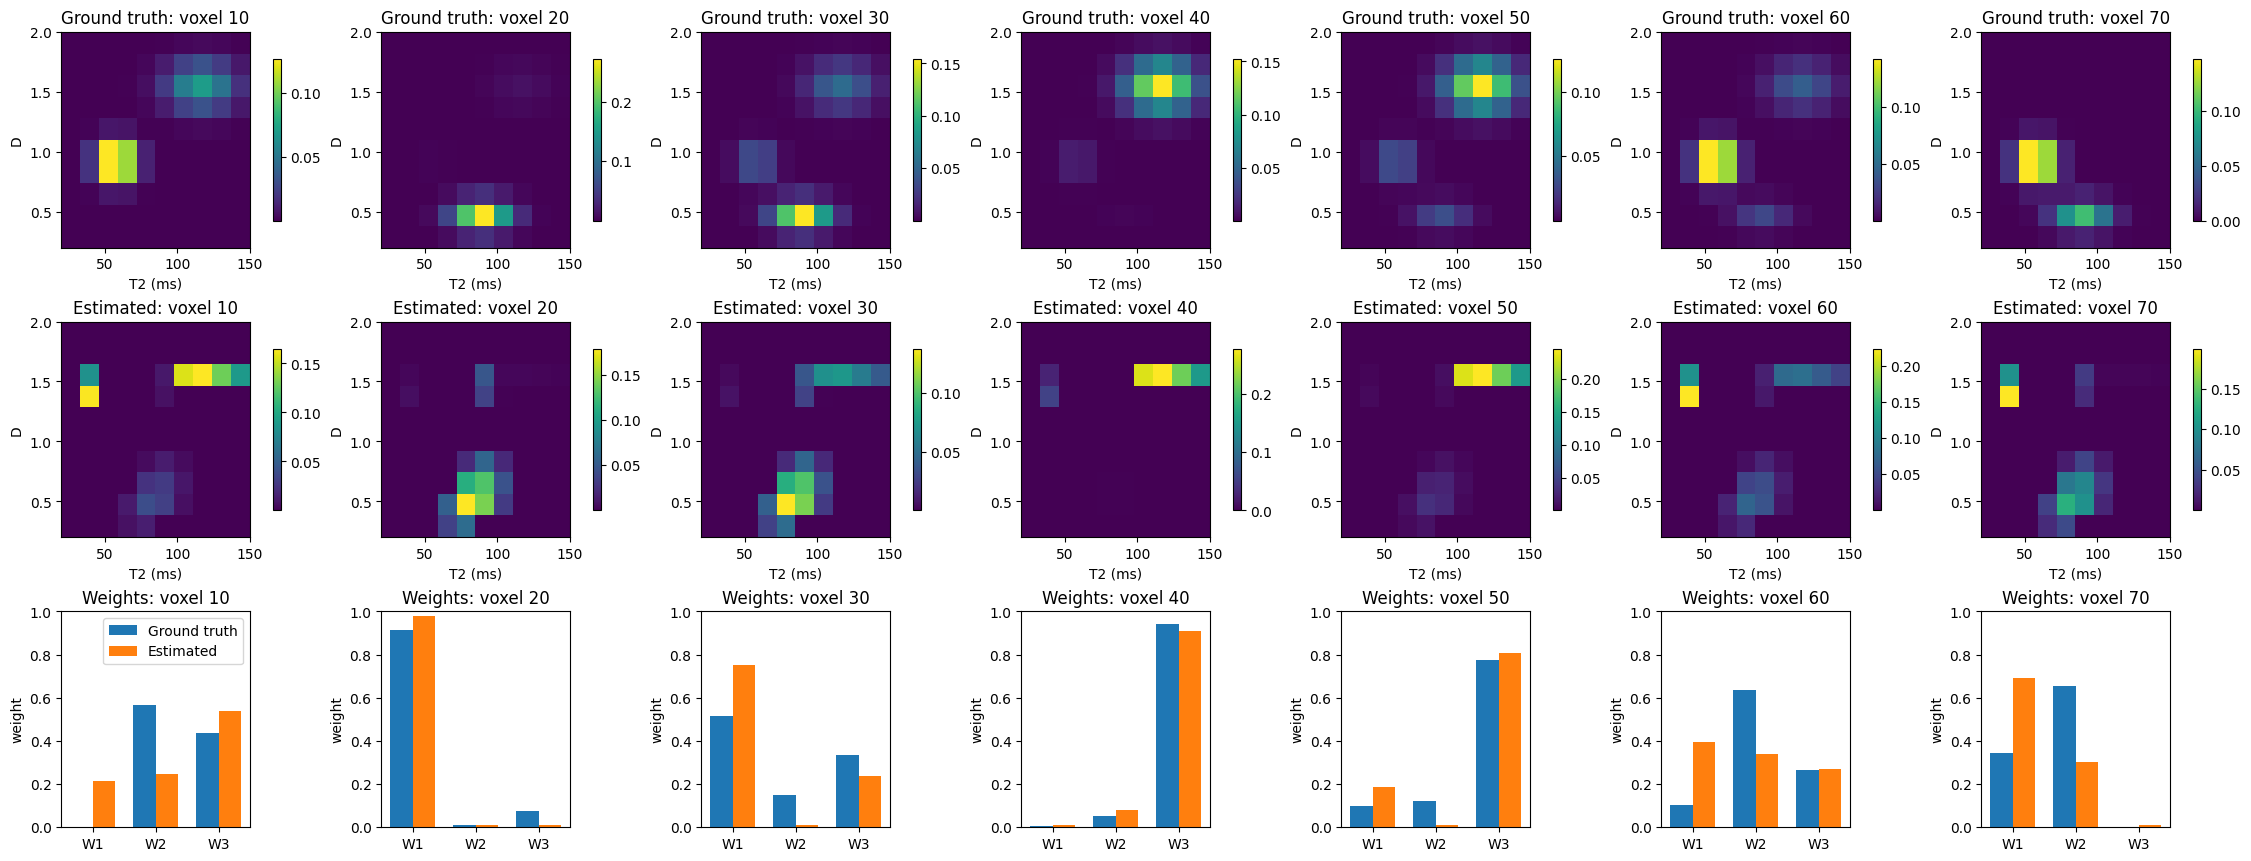

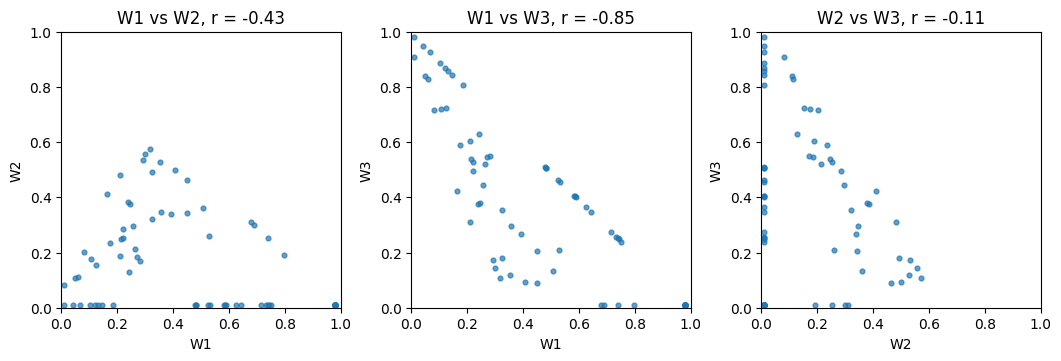

iter 0: loss=3138.6765, fit_err=184825.652371, sigma2=36.000000
iter 100: loss=2577.5772, fit_err=151138.082442, sigma2=36.000000
iter 200: loss=2577.5768, fit_err=151138.226785, sigma2=36.000000
Seed 1, entropy prior: estimated C, W MAE 0.174


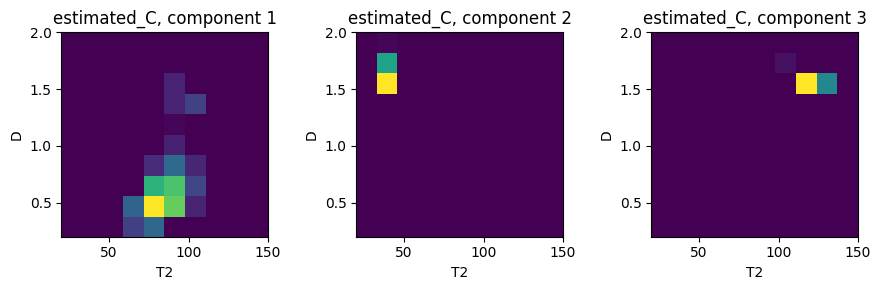

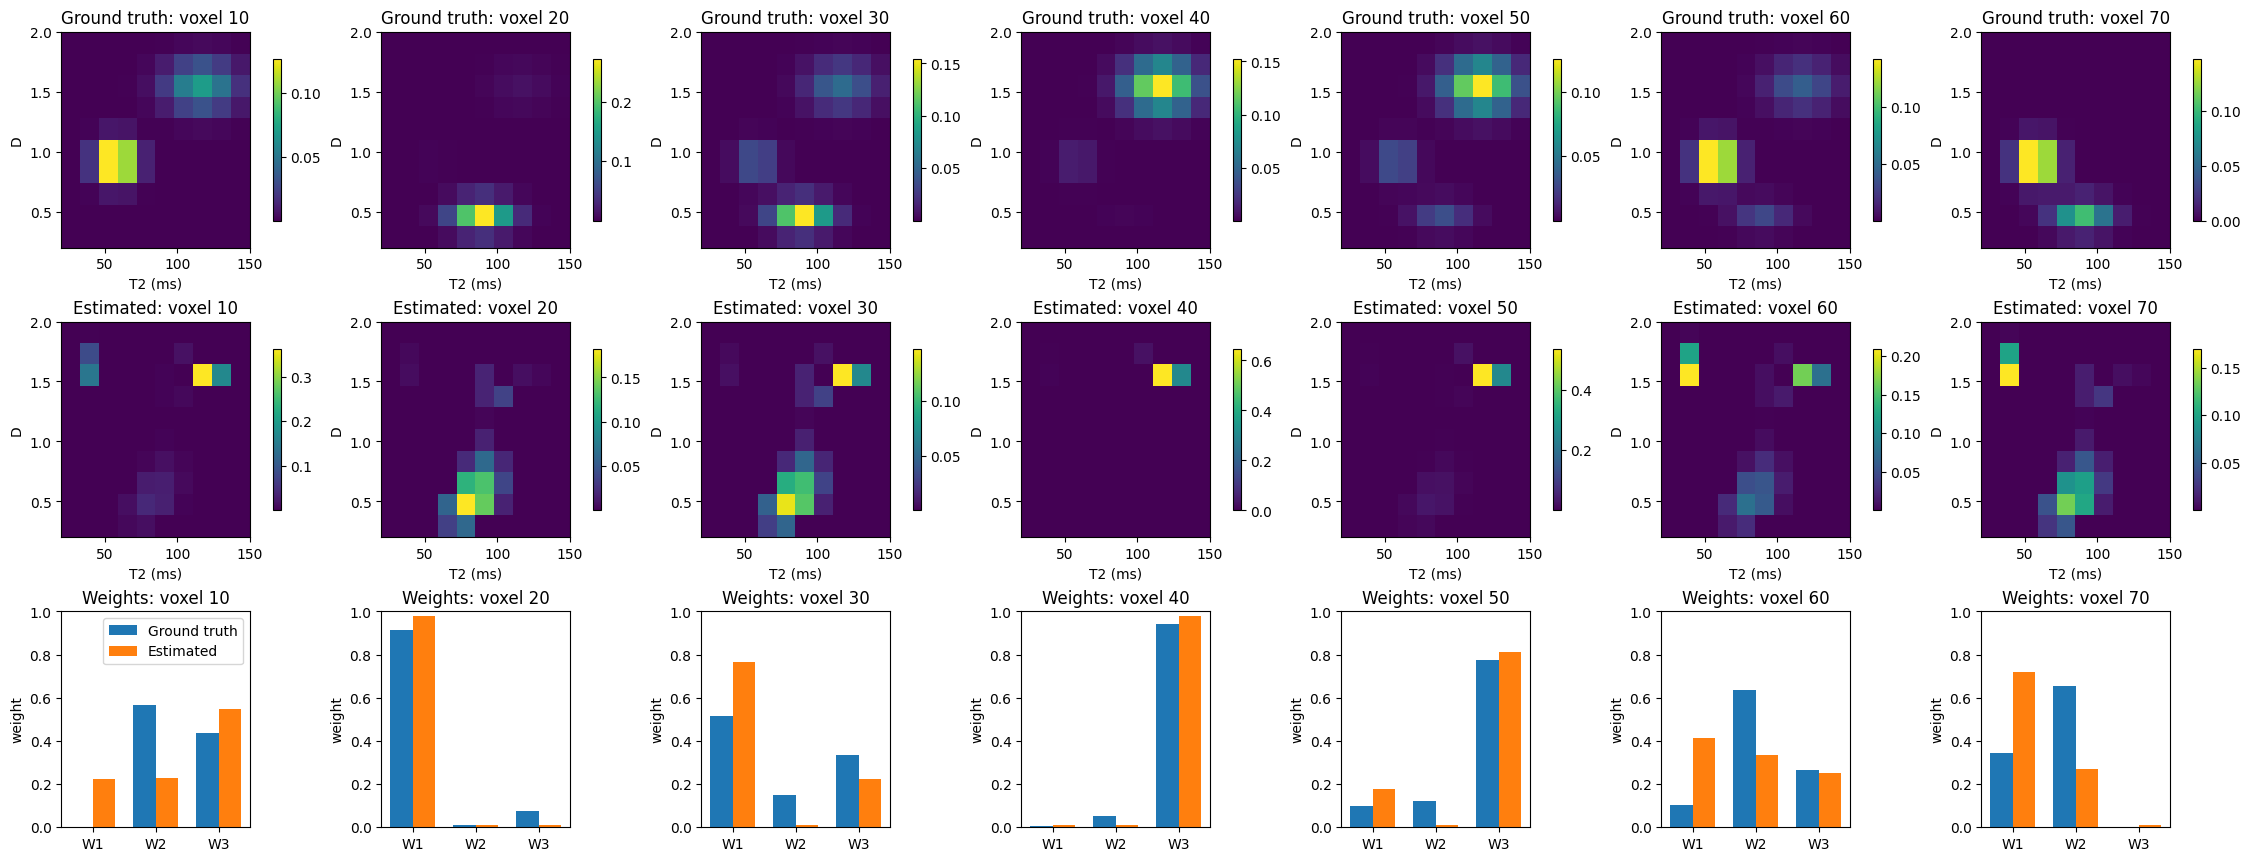

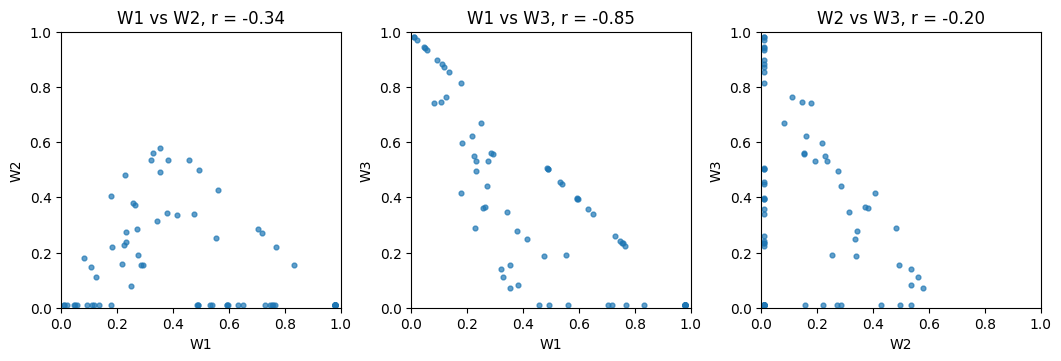

Seed 2: true C (first row) vs initial C (second row), starting W MAE 0.212


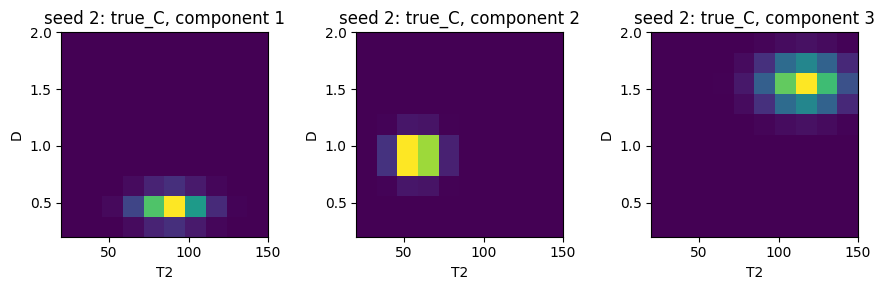

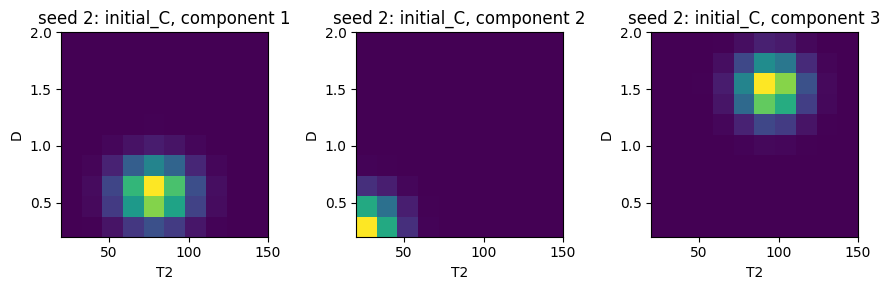



iter 0: loss=2143.8728, fit_err=150685.695555, sigma2=36.000000
iter 100: loss=1876.5024, fit_err=137473.695235, sigma2=36.000000
iter 200: loss=1876.5021, fit_err=137473.652758, sigma2=36.000000
Seed 2, dirichlet prior: estimated C, W MAE 0.148


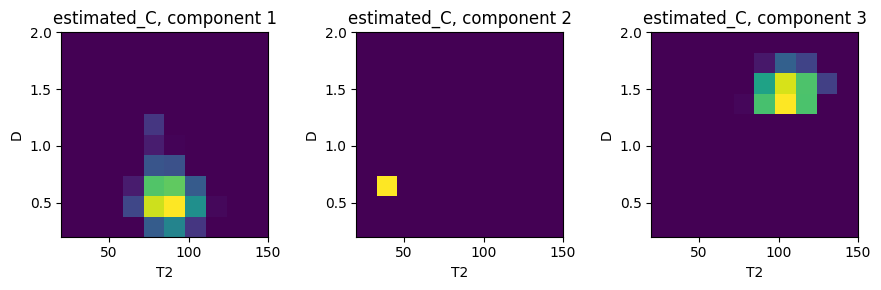

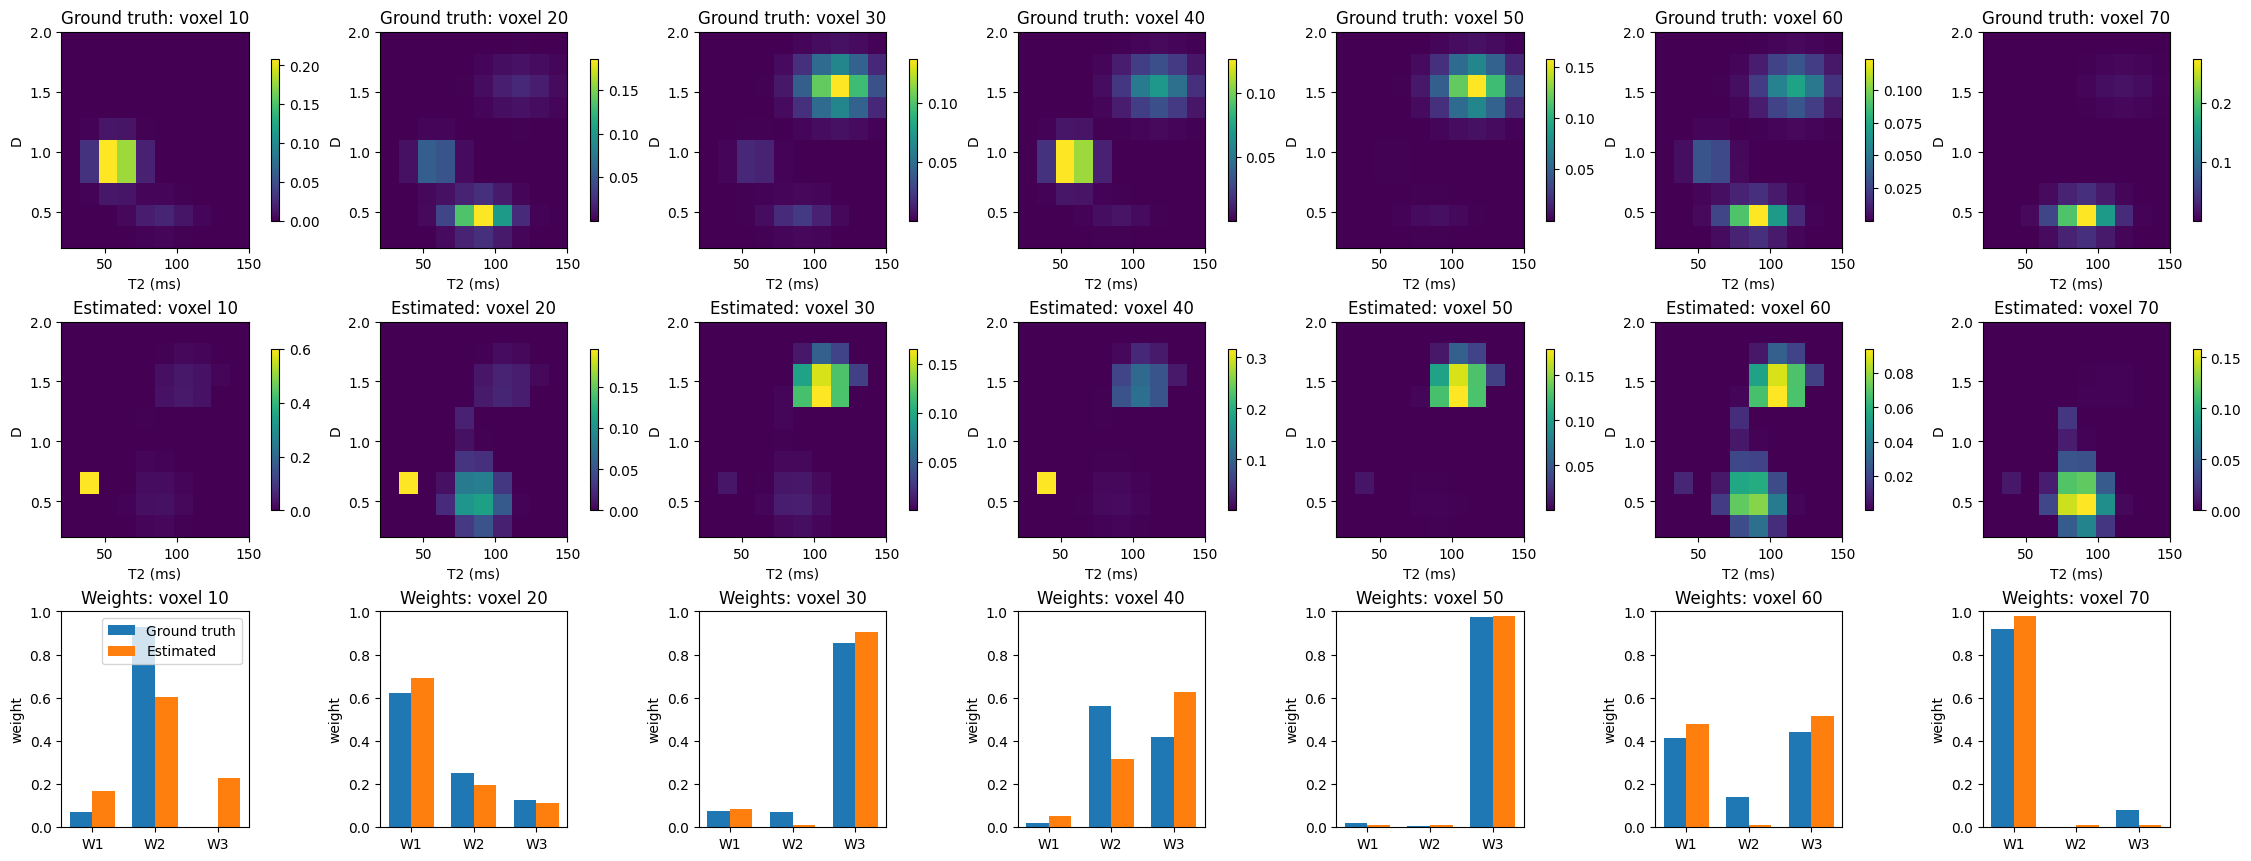

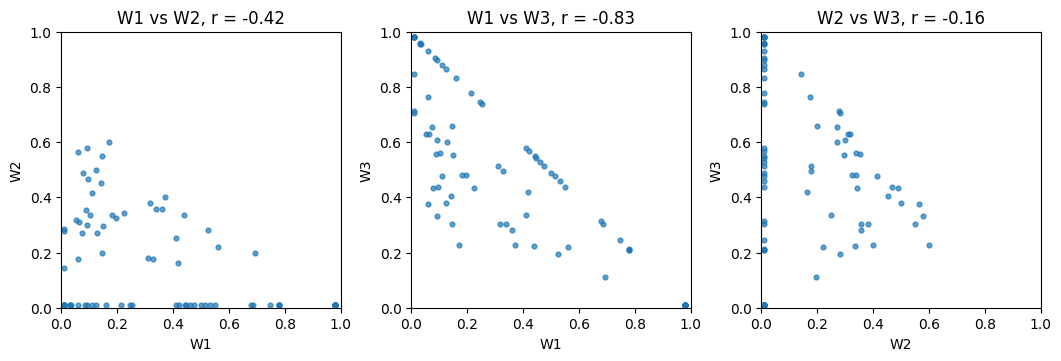

iter 0: loss=2633.8430, fit_err=152845.609293, sigma2=36.000000
iter 100: loss=2408.4298, fit_err=140529.034385, sigma2=36.000000
iter 200: loss=2408.4295, fit_err=140529.185701, sigma2=36.000000
Seed 2, entropy prior: estimated C, W MAE 0.159


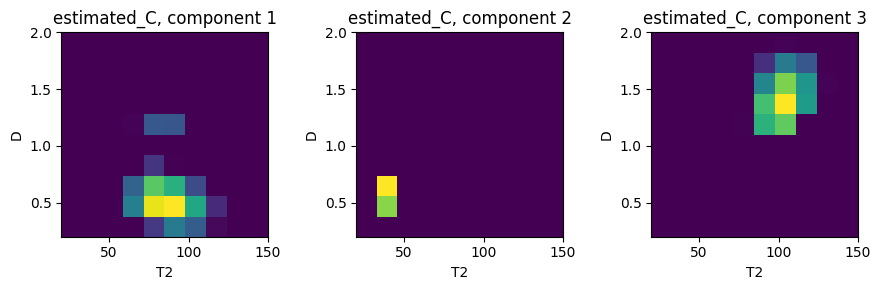

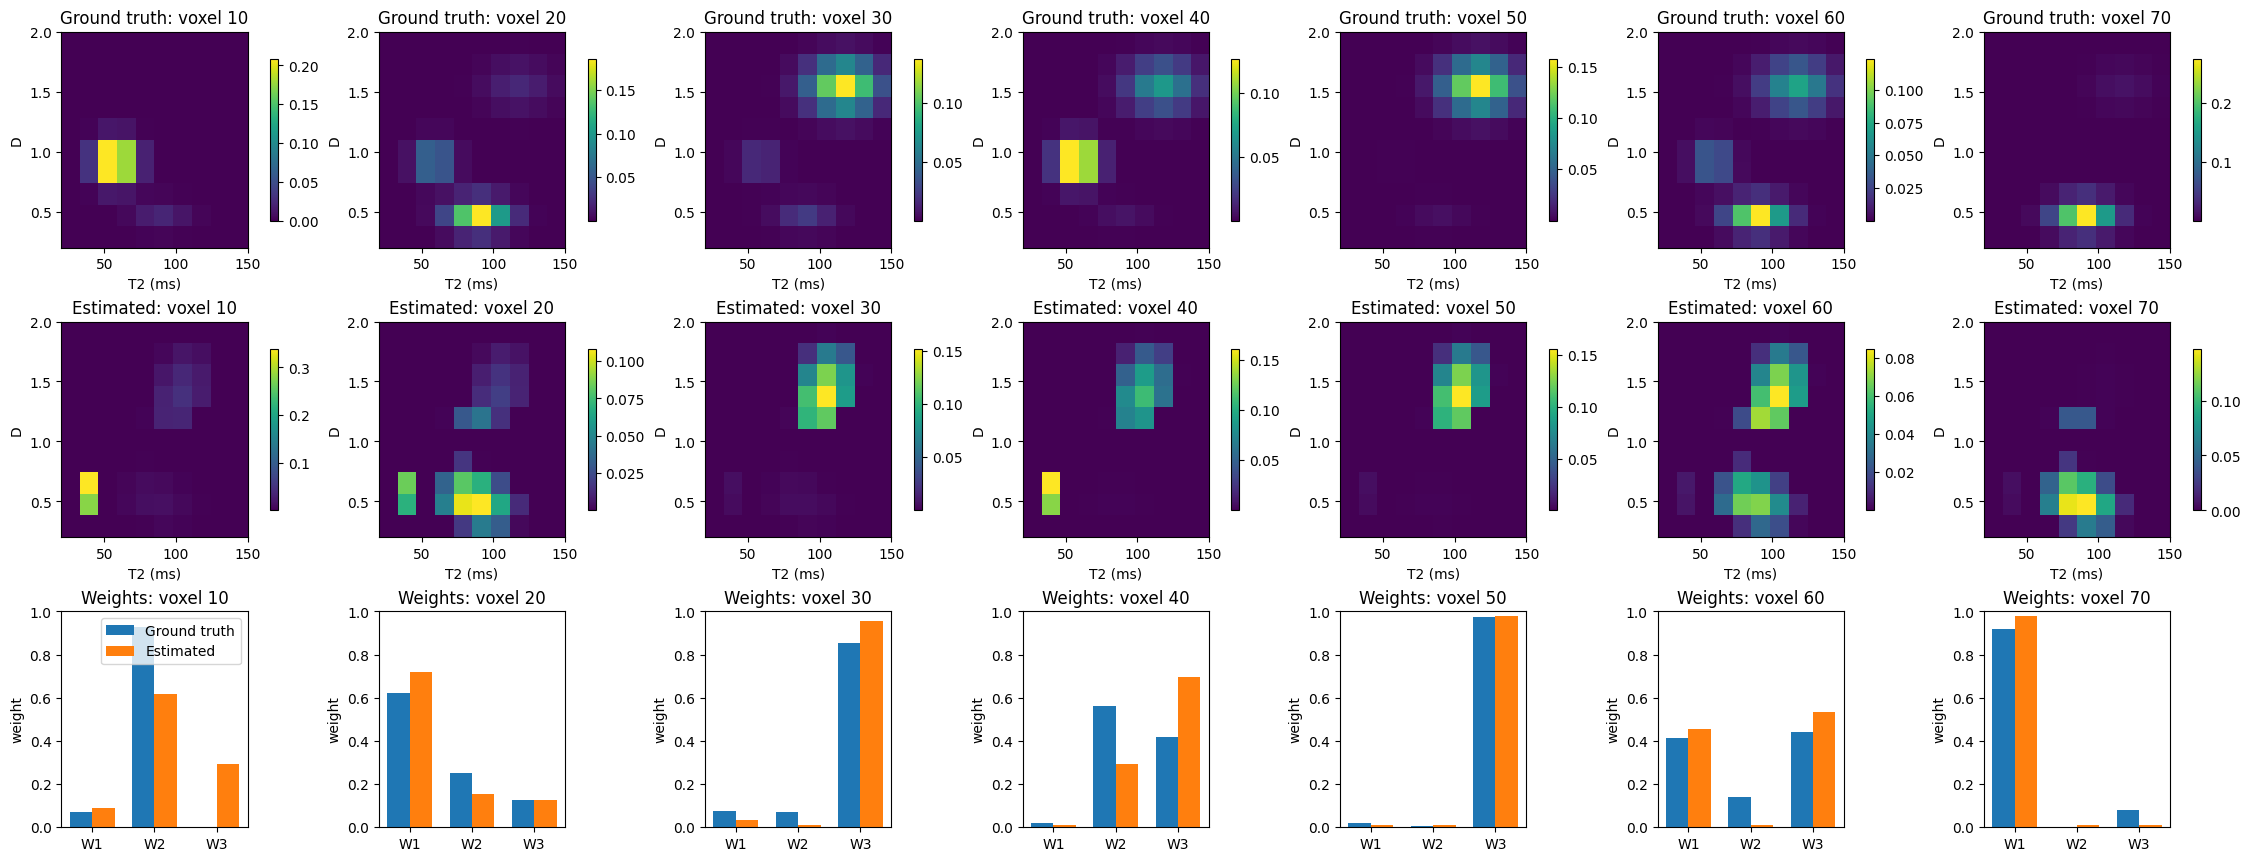

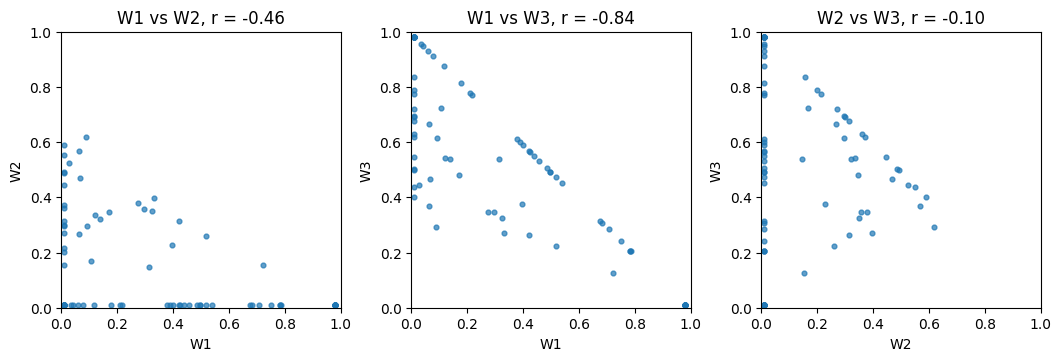

Seed 3: true C (first row) vs initial C (second row), starting W MAE 0.292


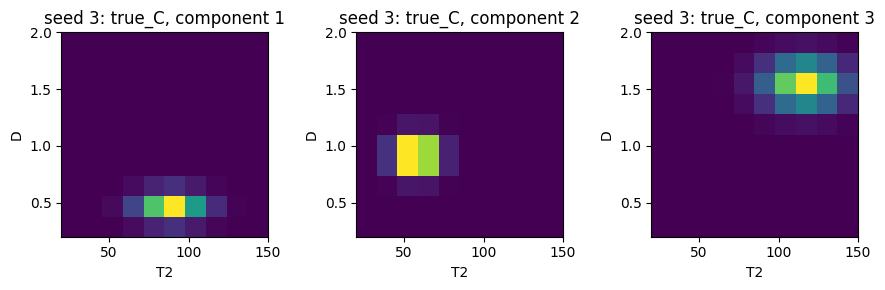

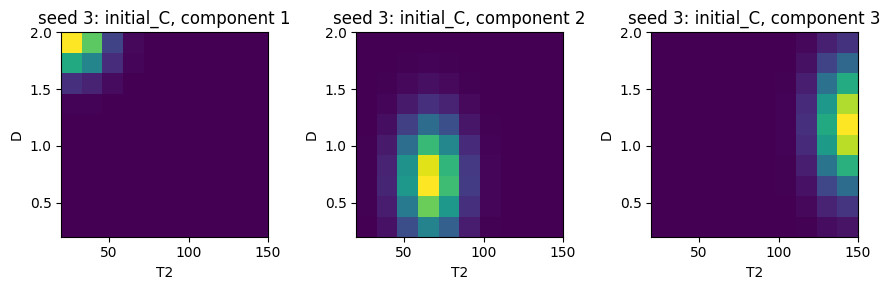



iter 0: loss=3237.4053, fit_err=225720.754012, sigma2=36.000000
iter 100: loss=2057.7392, fit_err=148681.721848, sigma2=36.000000
iter 200: loss=2057.7390, fit_err=148683.119398, sigma2=36.000000
Seed 3, dirichlet prior: estimated C, W MAE 0.148


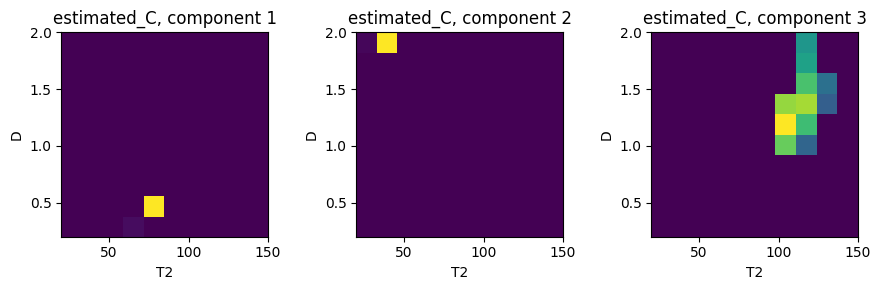

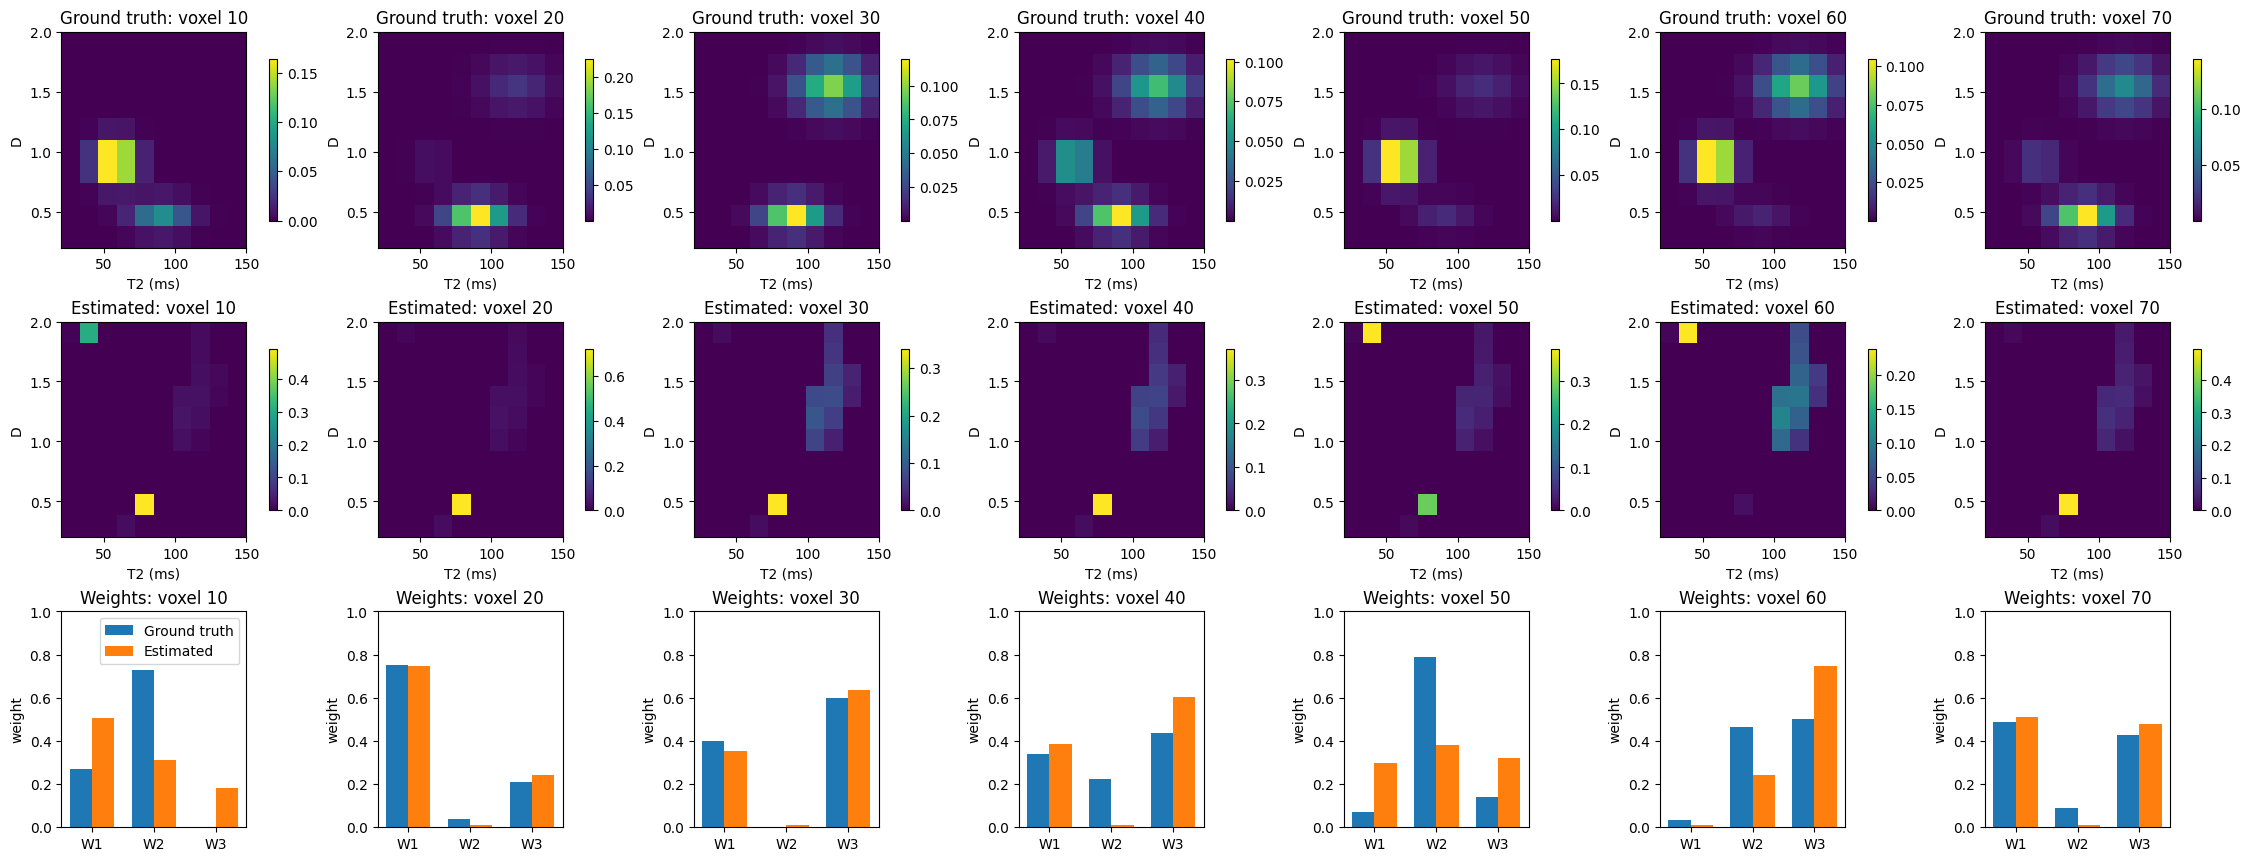

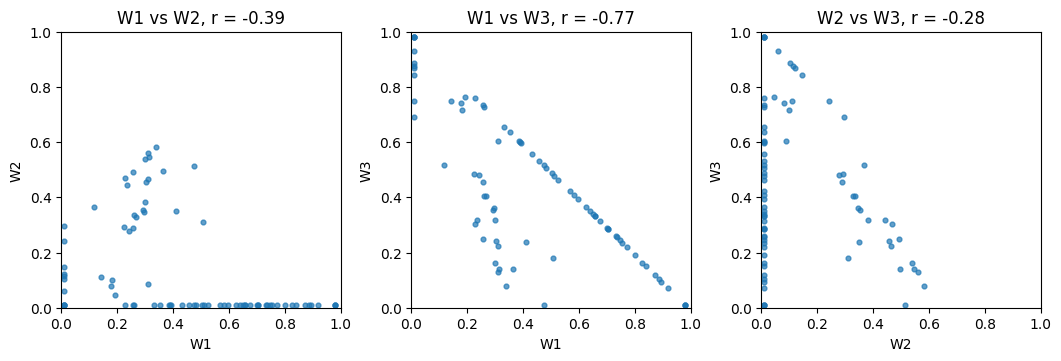

iter 0: loss=3918.4943, fit_err=234027.414162, sigma2=36.000000
iter 100: loss=2581.6362, fit_err=150076.929472, sigma2=36.000000
iter 200: loss=2581.2781, fit_err=150060.091174, sigma2=36.000000
Seed 3, entropy prior: estimated C, W MAE 0.153


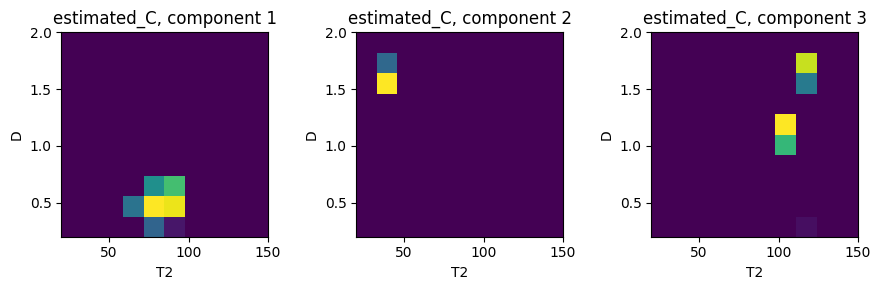

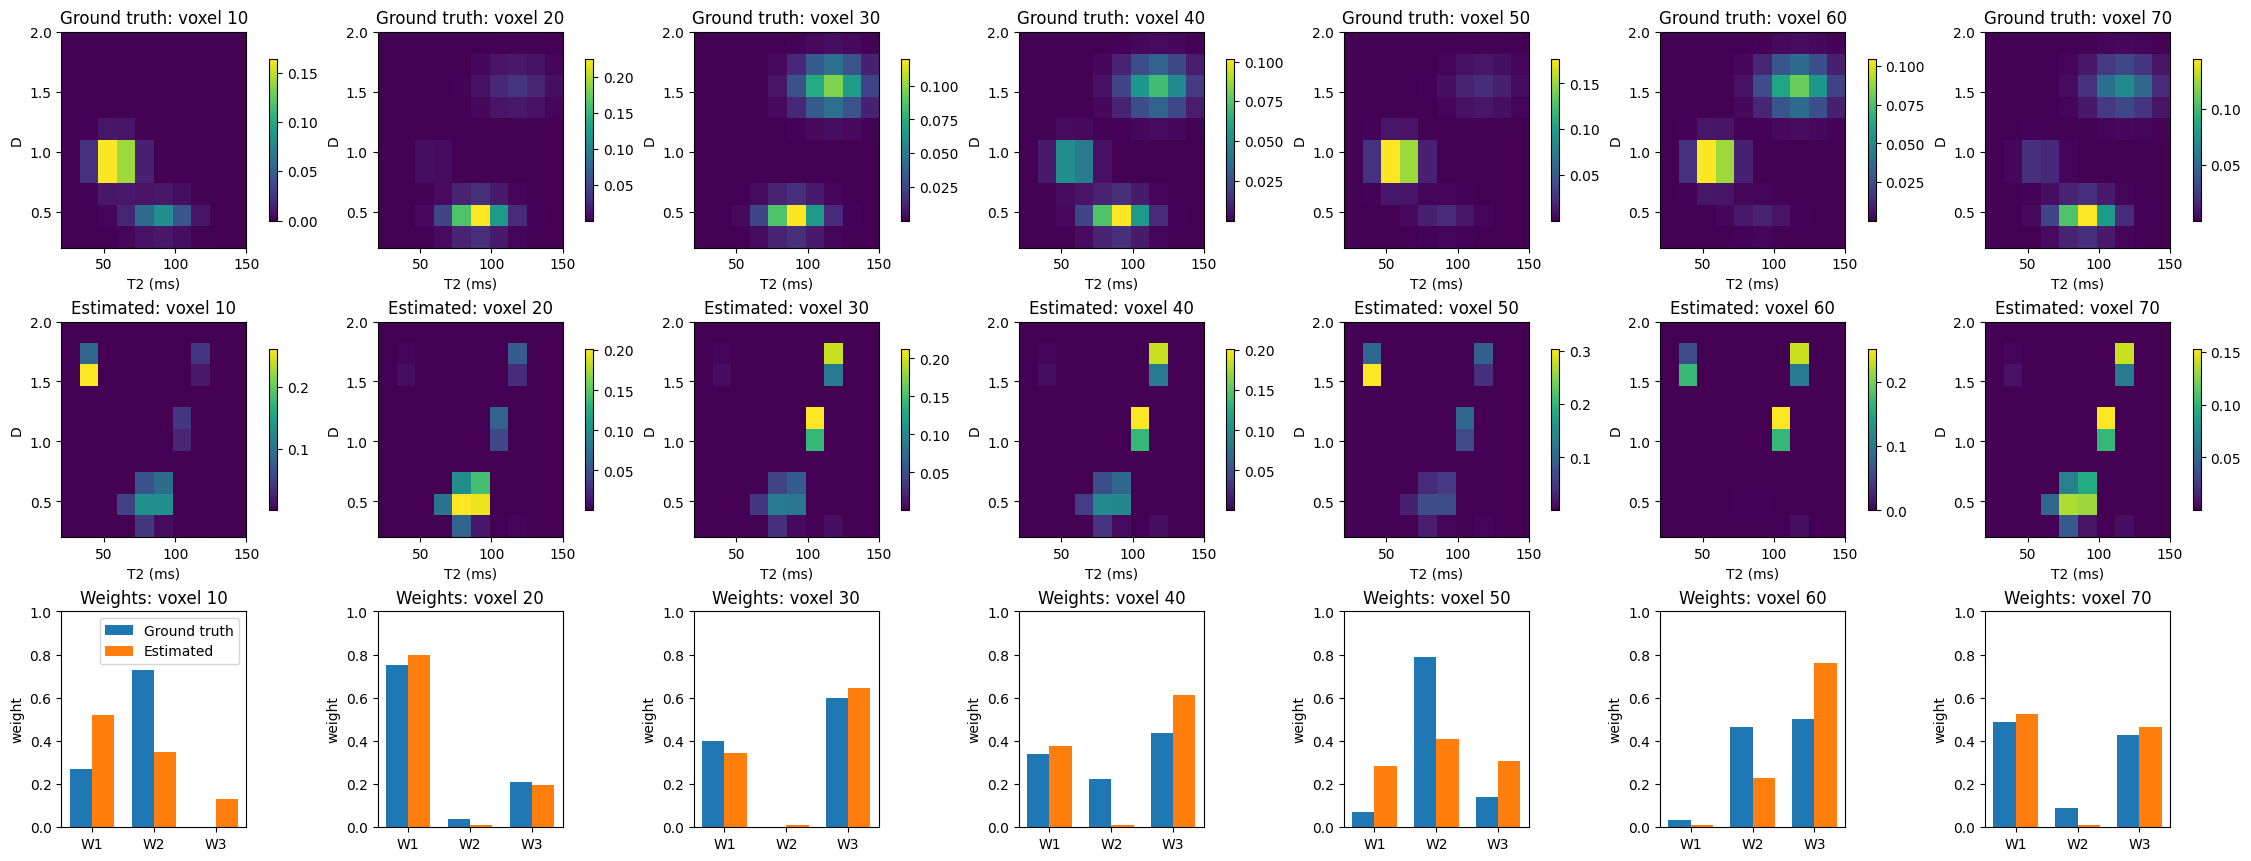

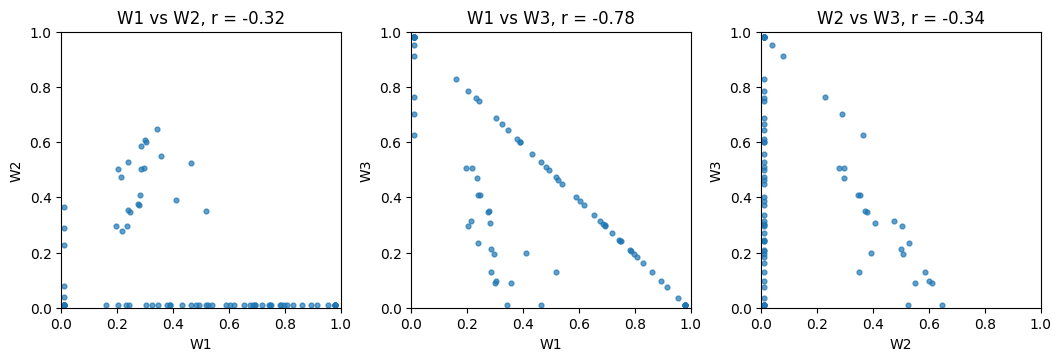

Seed 4: true C (first row) vs initial C (second row), starting W MAE 0.210


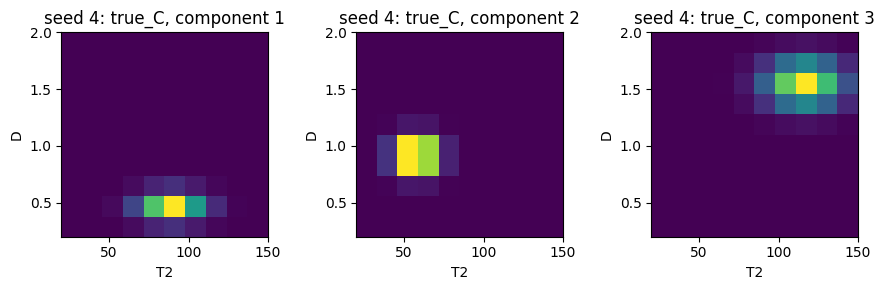

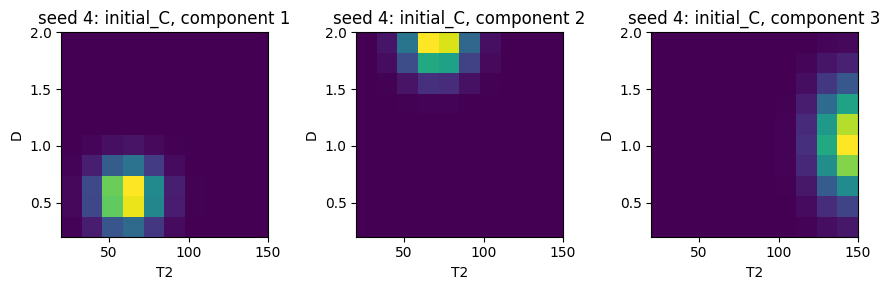



iter 0: loss=2622.2970, fit_err=187221.173389, sigma2=36.000000
iter 100: loss=1889.2672, fit_err=139265.862025, sigma2=36.000000
iter 200: loss=1889.2671, fit_err=139265.368681, sigma2=36.000000
Seed 4, dirichlet prior: estimated C, W MAE 0.126


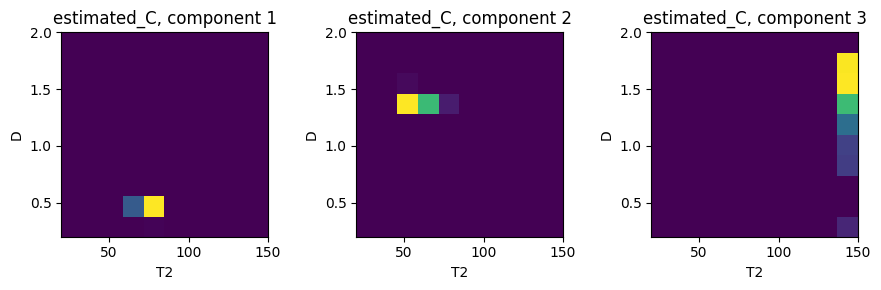

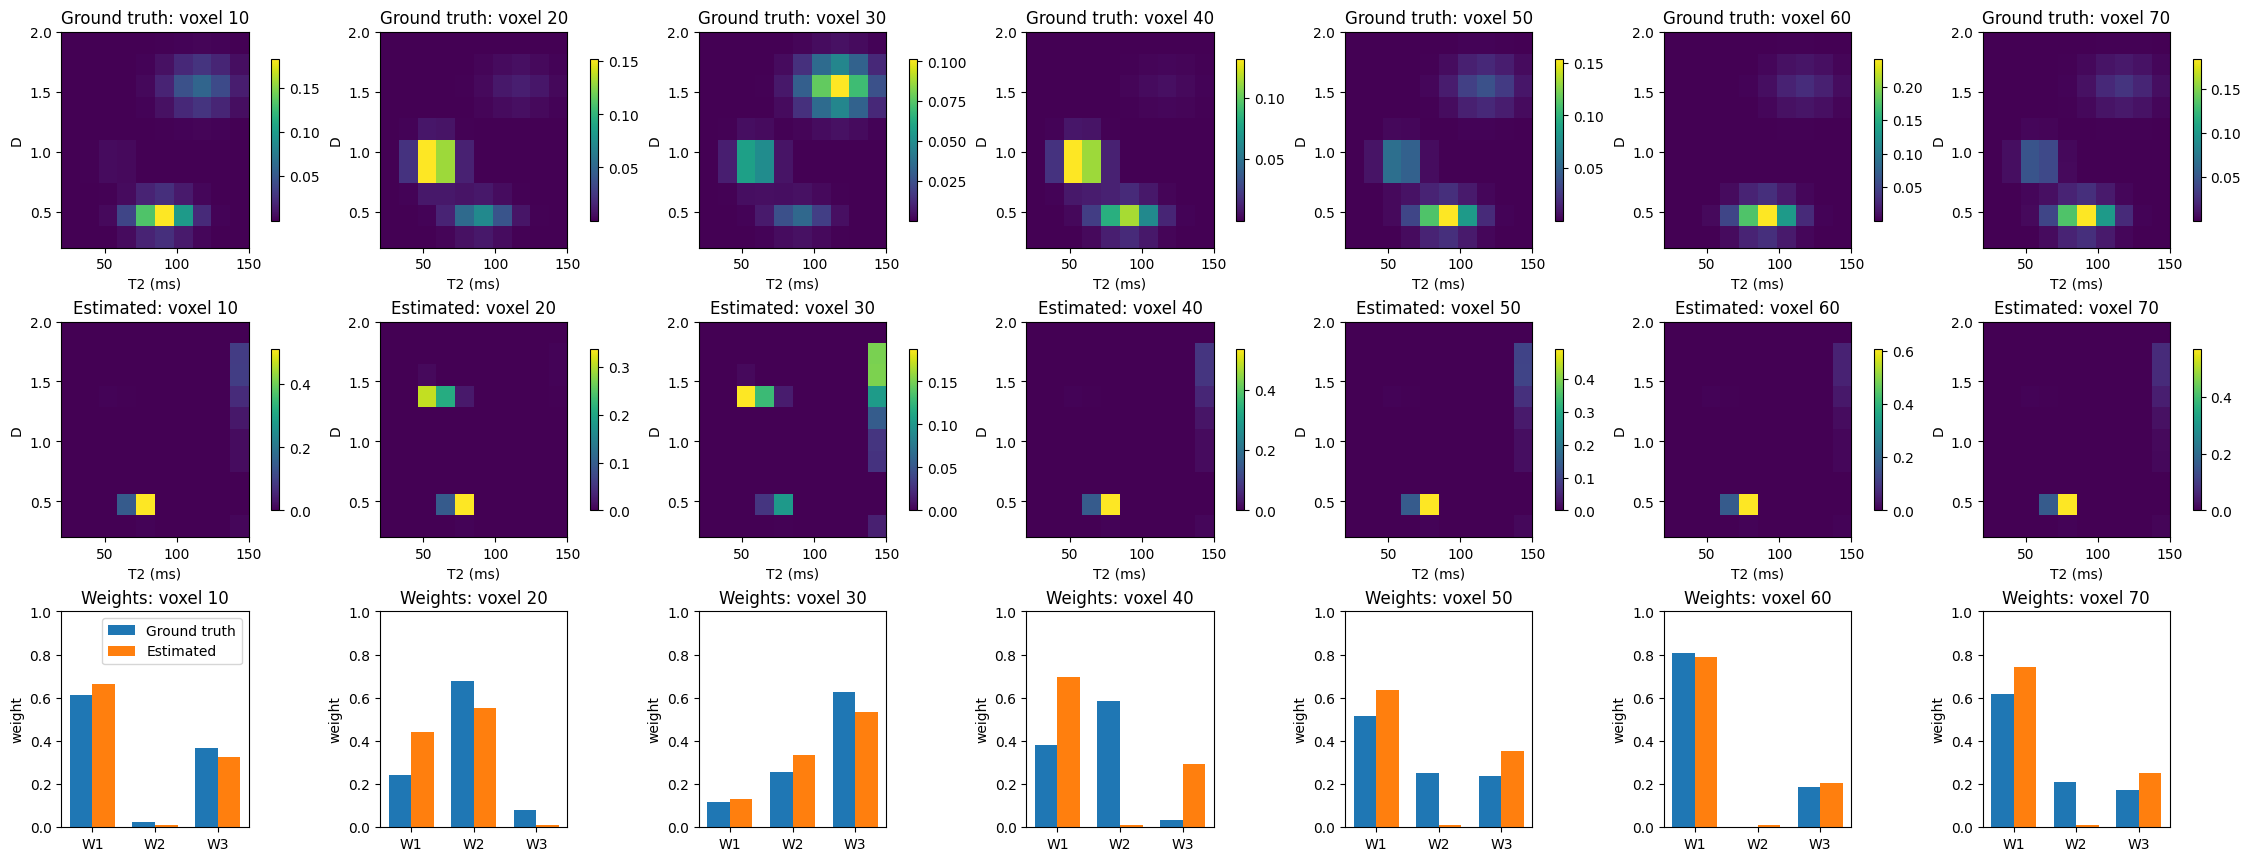

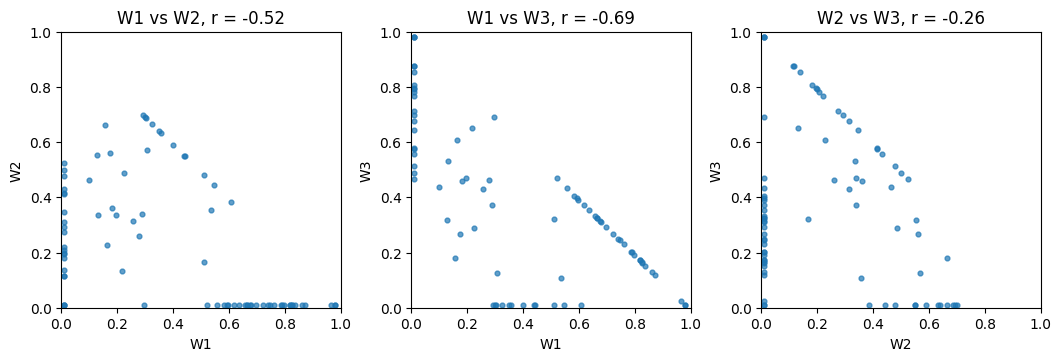

iter 0: loss=3251.6971, fit_err=189342.190257, sigma2=36.000000
iter 100: loss=2417.1598, fit_err=142650.620337, sigma2=36.000000
iter 200: loss=2416.9096, fit_err=142745.077261, sigma2=36.000000
Seed 4, entropy prior: estimated C, W MAE 0.123


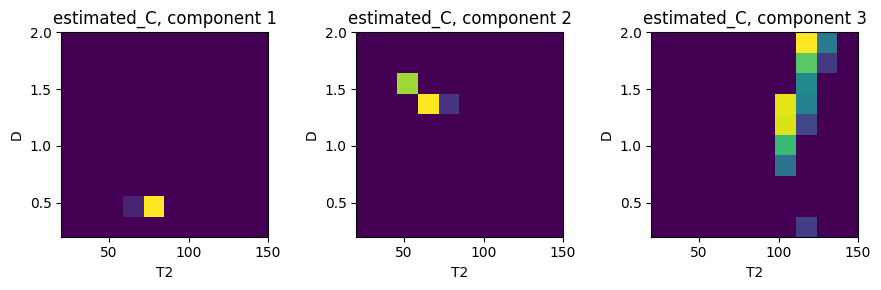

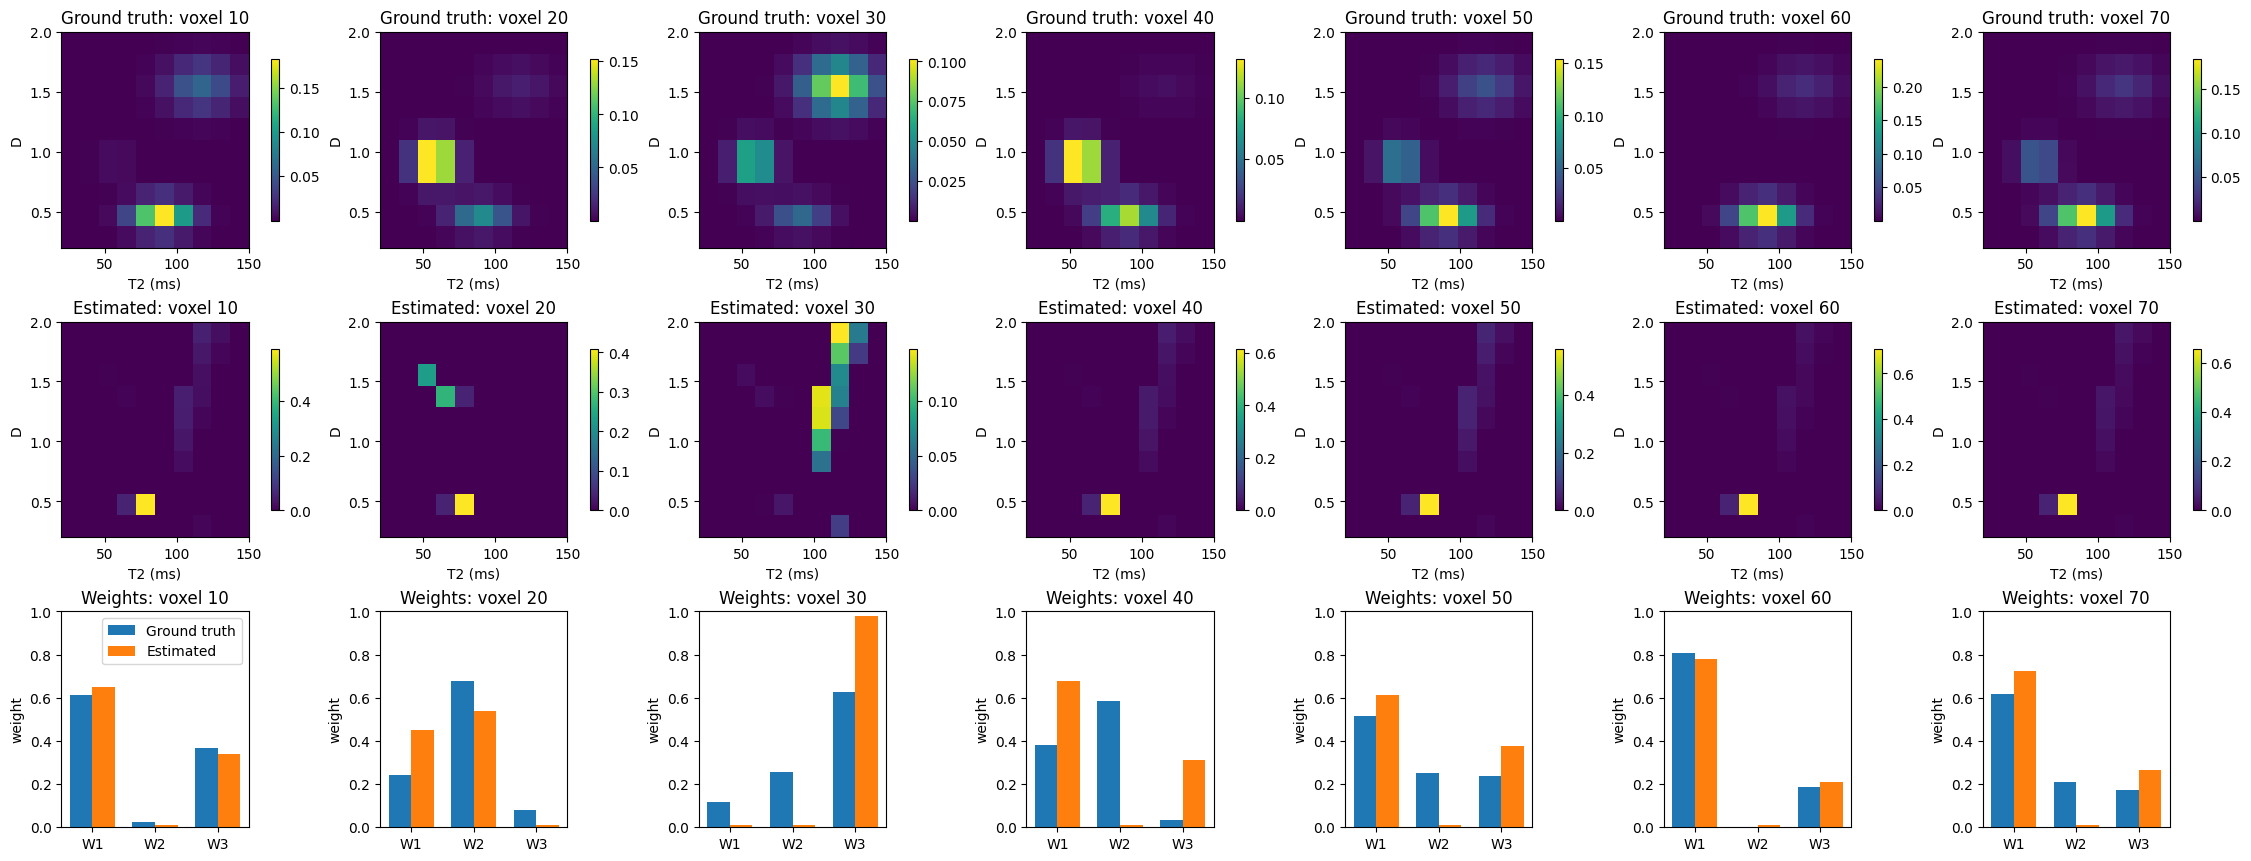

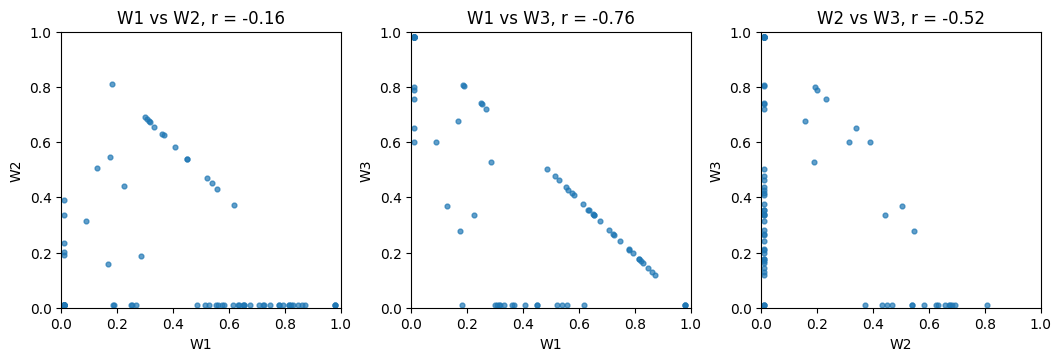

W MAE per seed: start, dirichlet, entropy
[[0.199 0.159 0.174]
 [0.28  0.167 0.174]
 [0.212 0.148 0.159]
 [0.292 0.148 0.153]
 [0.21  0.126 0.123]]
mean: [0.239 0.15  0.157]


In [36]:
# Dirichlet vs entropy prior on the same data, over several seeds — constrained C (non-negative, simplex on the D–T2 grid)
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

rows = []
for seed in range(5):
    rng_seed = np.random.default_rng(seed)
    alpha_true = 0.5
    W_true_dirichlet = rng_seed.dirichlet(alpha_true * np.ones(K), size=V).T

    # Calulate the signal Y = M0 * A * C_true * W_true
    Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng_seed)

    # Set intial conditions
    C0_dirichlet=define_initial_C_NNLS_mean(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
    Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat)

    M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

    W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

    C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

    print(f"Seed {seed}: true C (first row) vs initial C (second row), starting W MAE {np.mean(np.abs(W_true_dirichlet - W0_dirichlet)):.3f}")
    show_canonical_spectra([(f'seed {seed}: true_C', C_true)])
    show_canonical_spectra([(f'seed {seed}: initial_C', C0_dirichlet)])
    print("\n")

    errors = [np.mean(np.abs(W_true_dirichlet - W0_dirichlet))]
    for name, kwargs in priors.items():
        # C is optimised on the physical grid, so it starts from C0 (not Csmall0) and comes back as C directly
        W_est_dirichlet, _, C_est_dirichlet, *_ = run_constrained_optimisation(
            Y_dirichlet, U, s, Vmat, C0_dirichlet.copy(), M0_init_dirichlet, K=K, n_iter=300,
            sigma2=np.mean(sigma**2), lam=1e-2, alpha=1.0, W=W0_dirichlet.copy(),
            update_W_flag=True, update_C_flag=True, update_M0_flag=True,
            m0_prior=M0_init_dirichlet, m0_prior_sigma=10, alpha_update_start=5,
            c_sparsity=0.0, c_smoothness=10.0, c_diversity=0.0, c_maxiter=100, nD=nD, nT2=nT2,
            verbose_every=100, **kwargs)
        C_est_dirichlet, W_est_dirichlet = order_components(C_true, C_est_dirichlet, W_est_dirichlet, K)
        errors.append(np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
        print(f"Seed {seed}, {name} prior: estimated C, W MAE {errors[-1]:.3f}")
        show_canonical_spectra([(f'estimated_C', C_est_dirichlet)])

        F_true = C_true @ W_true_dirichlet
        F_est = C_est_dirichlet @ W_est_dirichlet
        show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show)
        show_weight_correlations(W_est_dirichlet)

    rows.append(errors)

print("W MAE per seed: start, dirichlet, entropy")
print(np.round(rows, 3))
print("mean:", np.round(np.mean(rows, axis=0), 3))
